In [1]:
import numpy as np
import networkx as nx
import itertools as it
import random as rd
import pickle as pk
import pandas as pd
from collections import (defaultdict,Counter)
import matplotlib.pyplot as plt
import scipy  
from scipy import stats


In [71]:
#Here, we import the disease-gene annotations for each source

with open('output/ncbi_disease_gene_clinvar_icd_dict.pickle', 'rb') as handle:
    ncbi_disease_gene_clinvar_icd_dict = pk.load(handle)

with open('output/disease_enhancer_genes_icd_dict.pickle', 'rb') as handle:
    disease_enhancer_genes_icd_dict = pk.load(handle)

with open('output/diseases_icd_id_genes_dict.pickle', 'rb') as handle:
    diseases_icd_id_genes_dict = pk.load(handle)

with open('output/omim_icd_gene_dict.pickle', 'rb') as handle:
    omim_icd_gene_dict = pk.load(handle)

with open('output/gwas_icd_gene_dict.pickle', 'rb') as handle:
    gwas_icd_gene_dict = pk.load(handle)

with open('output/OrphaData_icd_gene_dict.pickle', 'rb') as handle:
    OrphaData_icd_gene_dict = pk.load(handle)

with open('output/disgenet_icd10_genes_dict_unified_genelist.pickle', 'rb') as handle:
    disgenet_icd10_genes_dict_unified_genelist = pk.load(handle)

with open('output/opentargets_icd_unified_genelist.pickle', 'rb') as handle:
    opentargets_icd_unified_genelist = pk.load(handle)


In [174]:
import pickle as pk
import json

# helper: load pickle and make it JSON-safe
def load_pickle_as_jsonsafe(path):
    with open(path, "rb") as handle:
        obj = pk.load(handle)
    # convert sets to lists
    if isinstance(obj, dict):
        return {k: list(v) if isinstance(v, set) else v for k, v in obj.items()}
    return obj

# mapping: filename prefix -> variable
files = {
    "ncbi_disease_gene_clinvar_icd_dict":         "output/ncbi_disease_gene_clinvar_icd_dict.pickle",
    "disease_enhancer_genes_icd_dict":            "output/disease_enhancer_genes_icd_dict.pickle",
    "diseases_icd_id_genes_dict":                 "output/diseases_icd_id_genes_dict.pickle",
    "omim_icd_gene_dict":                         "output/omim_icd_gene_dict.pickle",
    "gwas_icd_gene_dict":                         "output/gwas_icd_gene_dict.pickle",
    "OrphaData_icd_gene_dict":                    "output/OrphaData_icd_gene_dict.pickle",
    "disgenet_icd10_genes_dict_unified_genelist": "output/disgenet_icd10_genes_dict_unified_genelist.pickle",
    "opentargets_icd_unified_genelist":           "output/opentargets_icd_unified_genelist.pickle",
}

all_dicts = {}
for name, path in files.items():
    data = load_pickle_as_jsonsafe(path)
    all_dicts[name] = data
    # write individual JSON
    with open(f"{name}.json", "w") as f:
        json.dump(data, f)

# optional: one combined JSON
with open("all_disease_gene_dicts.json", "w") as f:
    json.dump(all_dicts, f)

print("Exported individual JSON files and combined JSON: all_disease_gene_dicts.json")


Exported individual JSON files and combined JSON: all_disease_gene_dicts.json


In [176]:
import pickle as pk
import json
import math

def json_safe(x):
    # recurse and sanitize
    if isinstance(x, dict):
        return {str(k): json_safe(v) for k, v in x.items()}
    if isinstance(x, (list, tuple, set)):
        # dedupe while preserving order
        seen, out = set(), []
        for v in x:
            v2 = json_safe(v)
            key = json.dumps(v2, sort_keys=True, ensure_ascii=False)
            if key not in seen and v2 is not None:
                seen.add(key); out.append(v2)
        return out
    if isinstance(x, float):
        if math.isnan(x) or math.isinf(x):
            return None
        return x
    if x is None:
        return None
    return x  # str/int/bool etc.

files = {
    "ncbi_disease_gene_clinvar_icd_dict":         "output/ncbi_disease_gene_clinvar_icd_dict.pickle",
    "disease_enhancer_genes_icd_dict":            "output/disease_enhancer_genes_icd_dict.pickle",
    "diseases_icd_id_genes_dict":                 "output/diseases_icd_id_genes_dict.pickle",
    "omim_icd_gene_dict":                         "output/omim_icd_gene_dict.pickle",
    "gwas_icd_gene_dict":                         "output/gwas_icd_gene_dict.pickle",
    "OrphaData_icd_gene_dict":                    "output/OrphaData_icd_gene_dict.pickle",
    "disgenet_icd10_genes_dict_unified_genelist": "output/disgenet_icd10_genes_dict_unified_genelist.pickle",
    "opentargets_icd_unified_genelist":           "output/opentargets_icd_unified_genelist.pickle",
}

all_dicts = {}
for name, path in files.items():
    with open(path, "rb") as f:
        obj = pk.load(f)
    all_dicts[name] = json_safe(obj)
    with open(f"{name}.json", "w", encoding="utf-8") as f:
        json.dump(all_dicts[name], f, ensure_ascii=False)

with open("all_disease_gene_dicts.json", "w", encoding="utf-8") as f:
    json.dump(all_dicts, f, ensure_ascii=False)


In [73]:
#Here, we create a source dictionary that collects disease-gene annotations for each source
sources_dict = {}

sources_dict['NCBI_ClinVar'] = ncbi_disease_gene_clinvar_icd_dict
sources_dict['Disease_ehancer'] = disease_enhancer_genes_icd_dict
sources_dict['DISEASES'] = diseases_icd_id_genes_dict
sources_dict['OMIM'] = omim_icd_gene_dict
sources_dict['GWAS'] = gwas_icd_gene_dict
sources_dict['Orphanet'] = OrphaData_icd_gene_dict
sources_dict['DisgeNET'] = disgenet_icd10_genes_dict_unified_genelist
sources_dict['OpenTargets'] = opentargets_icd_unified_genelist

In [172]:
omim_icd_gene_dict

{'C81': ['HDPA'],
 'N80': ['ENDO1'],
 'J93': ['FLCN', ' BHD'],
 'E50': ['BCO1', ' BCMO1', ' BCDO'],
 'C00': ['SCLC1'],
 'M08': ['LACC1', ' C13orf31', ' JUVAR'],
 'E11': ['ENPP1', ' PDNP1', ' NPPS', ' M6S1', ' PCA1', ' ARHR2', ' COLED'],
 'A90': ['CD209', ' CDSIGN'],
 'L88': ['PSTPIP1', ' PSTPIP', ' CD2BP1', ' PAPAS'],
 'C43': ['NRAS', ' ALPS4', ' NS6', ' CMNS', ' NCMS'],
 'E51': ['GLUL', ' GLNS', ' DEE116'],
 'D45': ['JAK2', ' THCYT3'],
 'D22': ['NRAS', ' ALPS4', ' NS6', ' CMNS', ' NCMS'],
 'D50': ['TMPRSS6', ' IRIDA'],
 'A36': ['HBEGF', ' DTR', ' DTSF', ' HEGFL'],
 'E73': ['ALDOB'],
 'C92': ['DNMT3A', ' TBRS', ' HESJAS'],
 'B51': ['ACKR1', ' DARC', ' FY', ' GPD', ' WBCQ1'],
 'B25': ['RAG1'],
 'B44': ['CLEC7A', ' CLECSF12', ' DECTIN1', ' CANDF4'],
 'I12': ['HNP1'],
 'I63': ['PRKCH', ' PKCL', ' PRKCL'],
 'K51': ['IL37', ' IL1F7', ' FIL1Z', ' IL1H4', ' IL1RP1', ' IBD31'],
 'F72': ['JARID2', ' JMJ', ' DIDDF'],
 'K21': ['GER'],
 'C82': ['BCL10', ' IMD37'],
 'G92': ['HTRA1', ' PRSS11', ' AR

In [75]:
 OrphaData_icd_gene_dict

{'D57': {'HBB'},
 'G43': {'ATP1A2', 'CACNA1A', 'PRRT2', 'SCN1A'},
 'G30': {'ABCA7', 'APP', 'PSEN1', 'PSEN2', 'SORL1', 'TOMM40', 'TREM2'},
 'C71': {'FLI1'},
 'I95': {'SLC6A2'},
 'E55': {'CYP27B1', 'CYP2R1'},
 'C93': {'ASXL1', 'ETV6', 'SRSF2'},
 'J93': {'FLCN'},
 'E50': {'BCO1'},
 'G90': {'ZFHX2'},
 'M88': {'TNFRSF11A', 'TNFRSF11B'},
 'E28': {'FMR1'},
 'C00': {'ING1', 'PTEN', 'TNFRSF10B'},
 'D86': {'BTNL2', 'HLA-DRB1'},
 'N11': {'FAN1'},
 'G10': {'JPH3'},
 'G51': {'ADCY5'},
 'D70': {'HAX1'},
 'C43': {'ATF1', 'CREB1', 'EWSR1'},
 'N25': {'SLC22A12', 'SLC2A9'},
 'E51': {'SLC19A3'},
 'D45': {'JAK2', 'MPL', 'TET2'},
 'D22': {'ACTB'},
 'D50': {'SLC11A2'},
 'H33': {'COL2A1'},
 'E26': {'CACNA1H'},
 'M80': {'PLS3'},
 'C45': {'BAP1'},
 'I42': {'ACTC1',
  'DTNA',
  'LDB3',
  'LMNA',
  'MIB1',
  'MIB2',
  'MYBPC3',
  'MYH7',
  'MYH7B',
  'PKP2',
  'PLEKHM2',
  'PRDM16',
  'TNNT2',
  'TPM1'},
 'C50': {'ATM',
  'BRCA1',
  'BRCA2',
  'CDH1',
  'KLLN',
  'NQO2',
  'PALB2',
  'RAD54L',
  'SLC22A18',
  'X

In [77]:
#Let's make the comparison across sources
sources_dict_cl = {}

for source,disdict in sources_dict.items():
    n_disdict = {}
    for dis,dis_set in disdict.items():
        if len(dis_set)>0:
            dis_set_cl = [gene for gene in dis_set if str(gene)!='nan']
            n_disdict[dis] = dis_set_cl
    sources_dict_cl[source] = n_disdict

for source,disdict in sources_dict_cl.items():
    tot_genelist = []
    for dis,geneset in disdict.items():
        for gene in geneset:
            if gene not in tot_genelist:
                tot_genelist.append(gene)
    print(source,len(disdict),len(tot_genelist))

sources_dict_cl_dis_comparison_dict = {}
sources_dict_cl_gene_comparison_dict = {}


for source1,disdict1 in sources_dict_cl.items():
    for source2,disdict2 in sources_dict_cl.items():
        dis_set1 = set(list(disdict1.keys()))
        dis_set2 = set(list(disdict2.keys()))
        geneset1 = set([gene for genelist in [genelist for genelist in list(disdict1.values())] for gene in genelist])
        geneset2 = set([gene for genelist in [genelist for genelist in list(disdict2.values())] for gene in genelist])
        sources_dict_cl_dis_comparison_dict[source1,source2] = dis_set1 & dis_set2
        sources_dict_cl_gene_comparison_dict[source1,source2] = geneset1 & geneset2

with open('output/sources_dict_cl_dis_comparison_dict.pickle', 'wb') as handle:
    pk.dump(sources_dict_cl_dis_comparison_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

with open('output/sources_dict_cl_gene_comparison_dict.pickle', 'wb') as handle:
    pk.dump(sources_dict_cl_gene_comparison_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

NCBI_ClinVar 230 1186
Disease_ehancer 81 182
DISEASES 463 3809
OMIM 132 521
GWAS 282 7602
Orphanet 274 685
DisgeNET 388 2836
OpenTargets 737 13767


In [67]:
#Let's import the source disease-gene annotations
with open('output/sources_dict_cl_dis_comparison_dict.pickle', 'rb') as handle:
    sources_dict_cl_dis_comparison_dict = pk.load(handle)

with open('output/sources_dict_cl_gene_comparison_dict.pickle', 'rb') as handle:
    sources_dict_cl_gene_comparison_dict = pk.load(handle)


In [15]:
sources_dict_cl_dis_comparison_dict.keys()

dict_keys([('NCBI_ClinVar', 'NCBI_ClinVar'), ('NCBI_ClinVar', 'Disease_ehancer'), ('NCBI_ClinVar', 'DISEASES'), ('NCBI_ClinVar', 'OMIM'), ('NCBI_ClinVar', 'GWAS'), ('NCBI_ClinVar', 'Orphanet'), ('NCBI_ClinVar', 'DisgeNET'), ('NCBI_ClinVar', 'OpenTargets'), ('Disease_ehancer', 'NCBI_ClinVar'), ('Disease_ehancer', 'Disease_ehancer'), ('Disease_ehancer', 'DISEASES'), ('Disease_ehancer', 'OMIM'), ('Disease_ehancer', 'GWAS'), ('Disease_ehancer', 'Orphanet'), ('Disease_ehancer', 'DisgeNET'), ('Disease_ehancer', 'OpenTargets'), ('DISEASES', 'NCBI_ClinVar'), ('DISEASES', 'Disease_ehancer'), ('DISEASES', 'DISEASES'), ('DISEASES', 'OMIM'), ('DISEASES', 'GWAS'), ('DISEASES', 'Orphanet'), ('DISEASES', 'DisgeNET'), ('DISEASES', 'OpenTargets'), ('OMIM', 'NCBI_ClinVar'), ('OMIM', 'Disease_ehancer'), ('OMIM', 'DISEASES'), ('OMIM', 'OMIM'), ('OMIM', 'GWAS'), ('OMIM', 'Orphanet'), ('OMIM', 'DisgeNET'), ('OMIM', 'OpenTargets'), ('GWAS', 'NCBI_ClinVar'), ('GWAS', 'Disease_ehancer'), ('GWAS', 'DISEASES'), 

Wrote matrix: upset_disease_matrix.csv (rows=1027, cols=64)


/var/folders/v7/09hywxp12yd031lcbmyzz46r0000gp/T/ipykernel_69200/2290422287.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: upset_disease.png


<Figure size 1000x600 with 0 Axes>

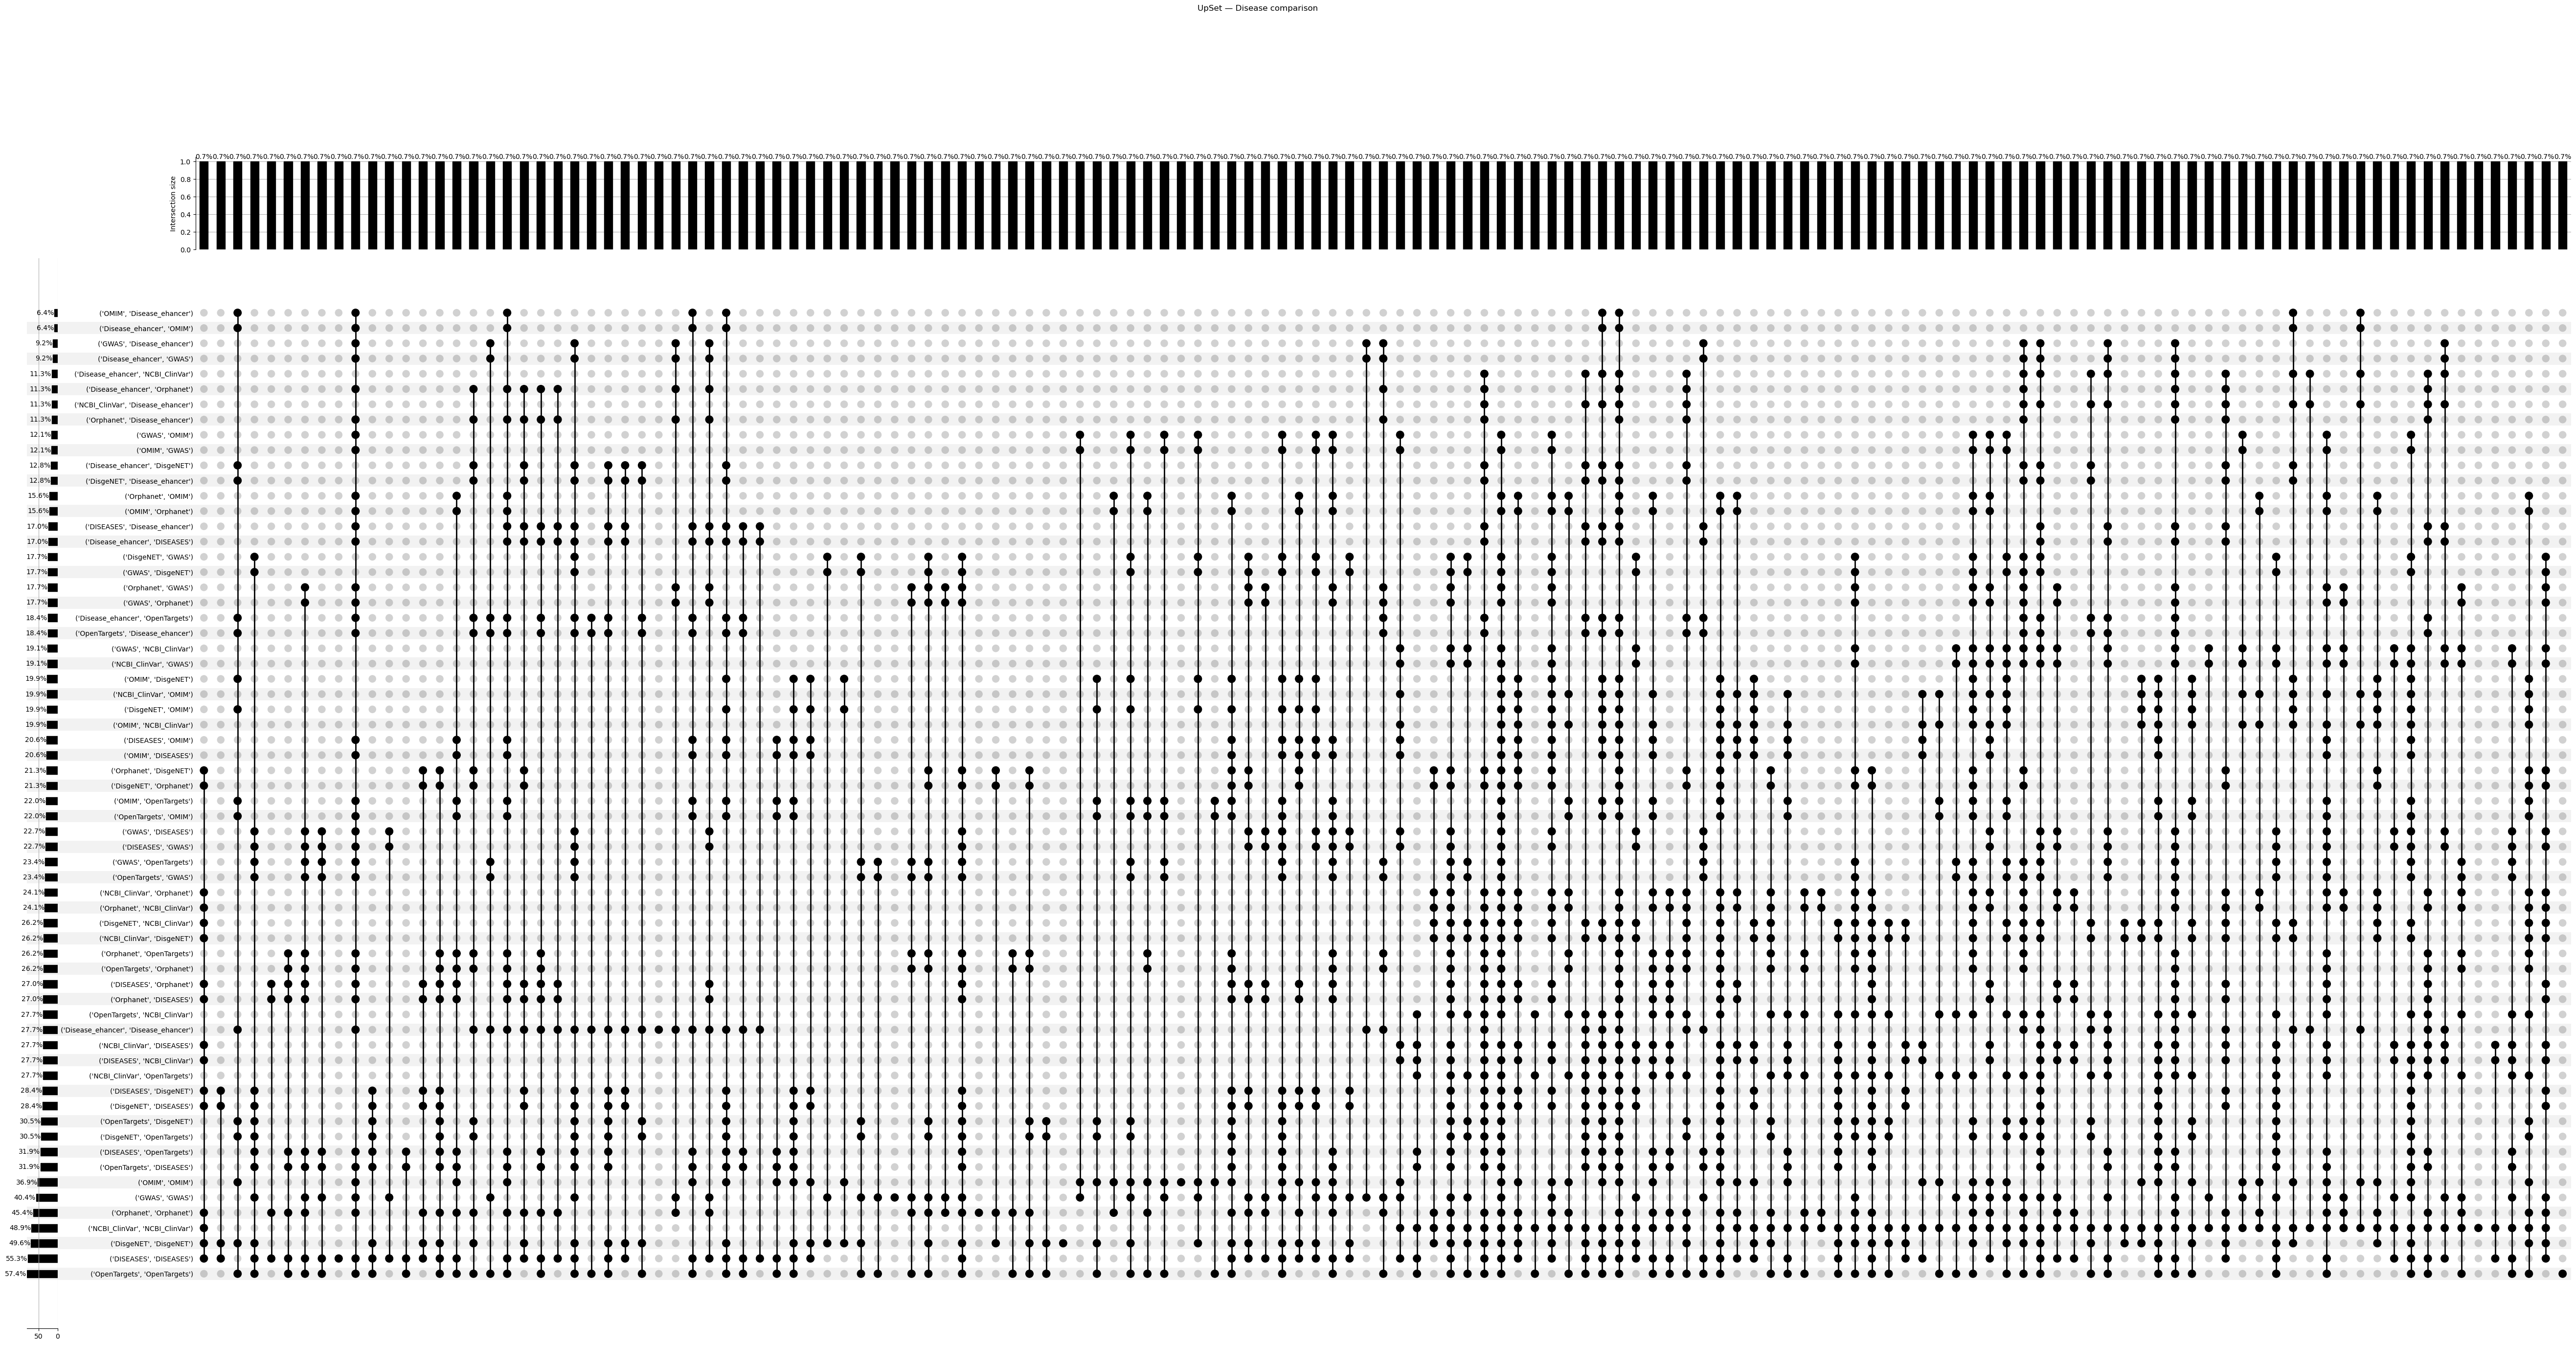

Wrote matrix: upset_gene_matrix.csv (rows=18830, cols=64)


/var/folders/v7/09hywxp12yd031lcbmyzz46r0000gp/T/ipykernel_69200/2290422287.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: upset_gene.png


<Figure size 1000x600 with 0 Axes>

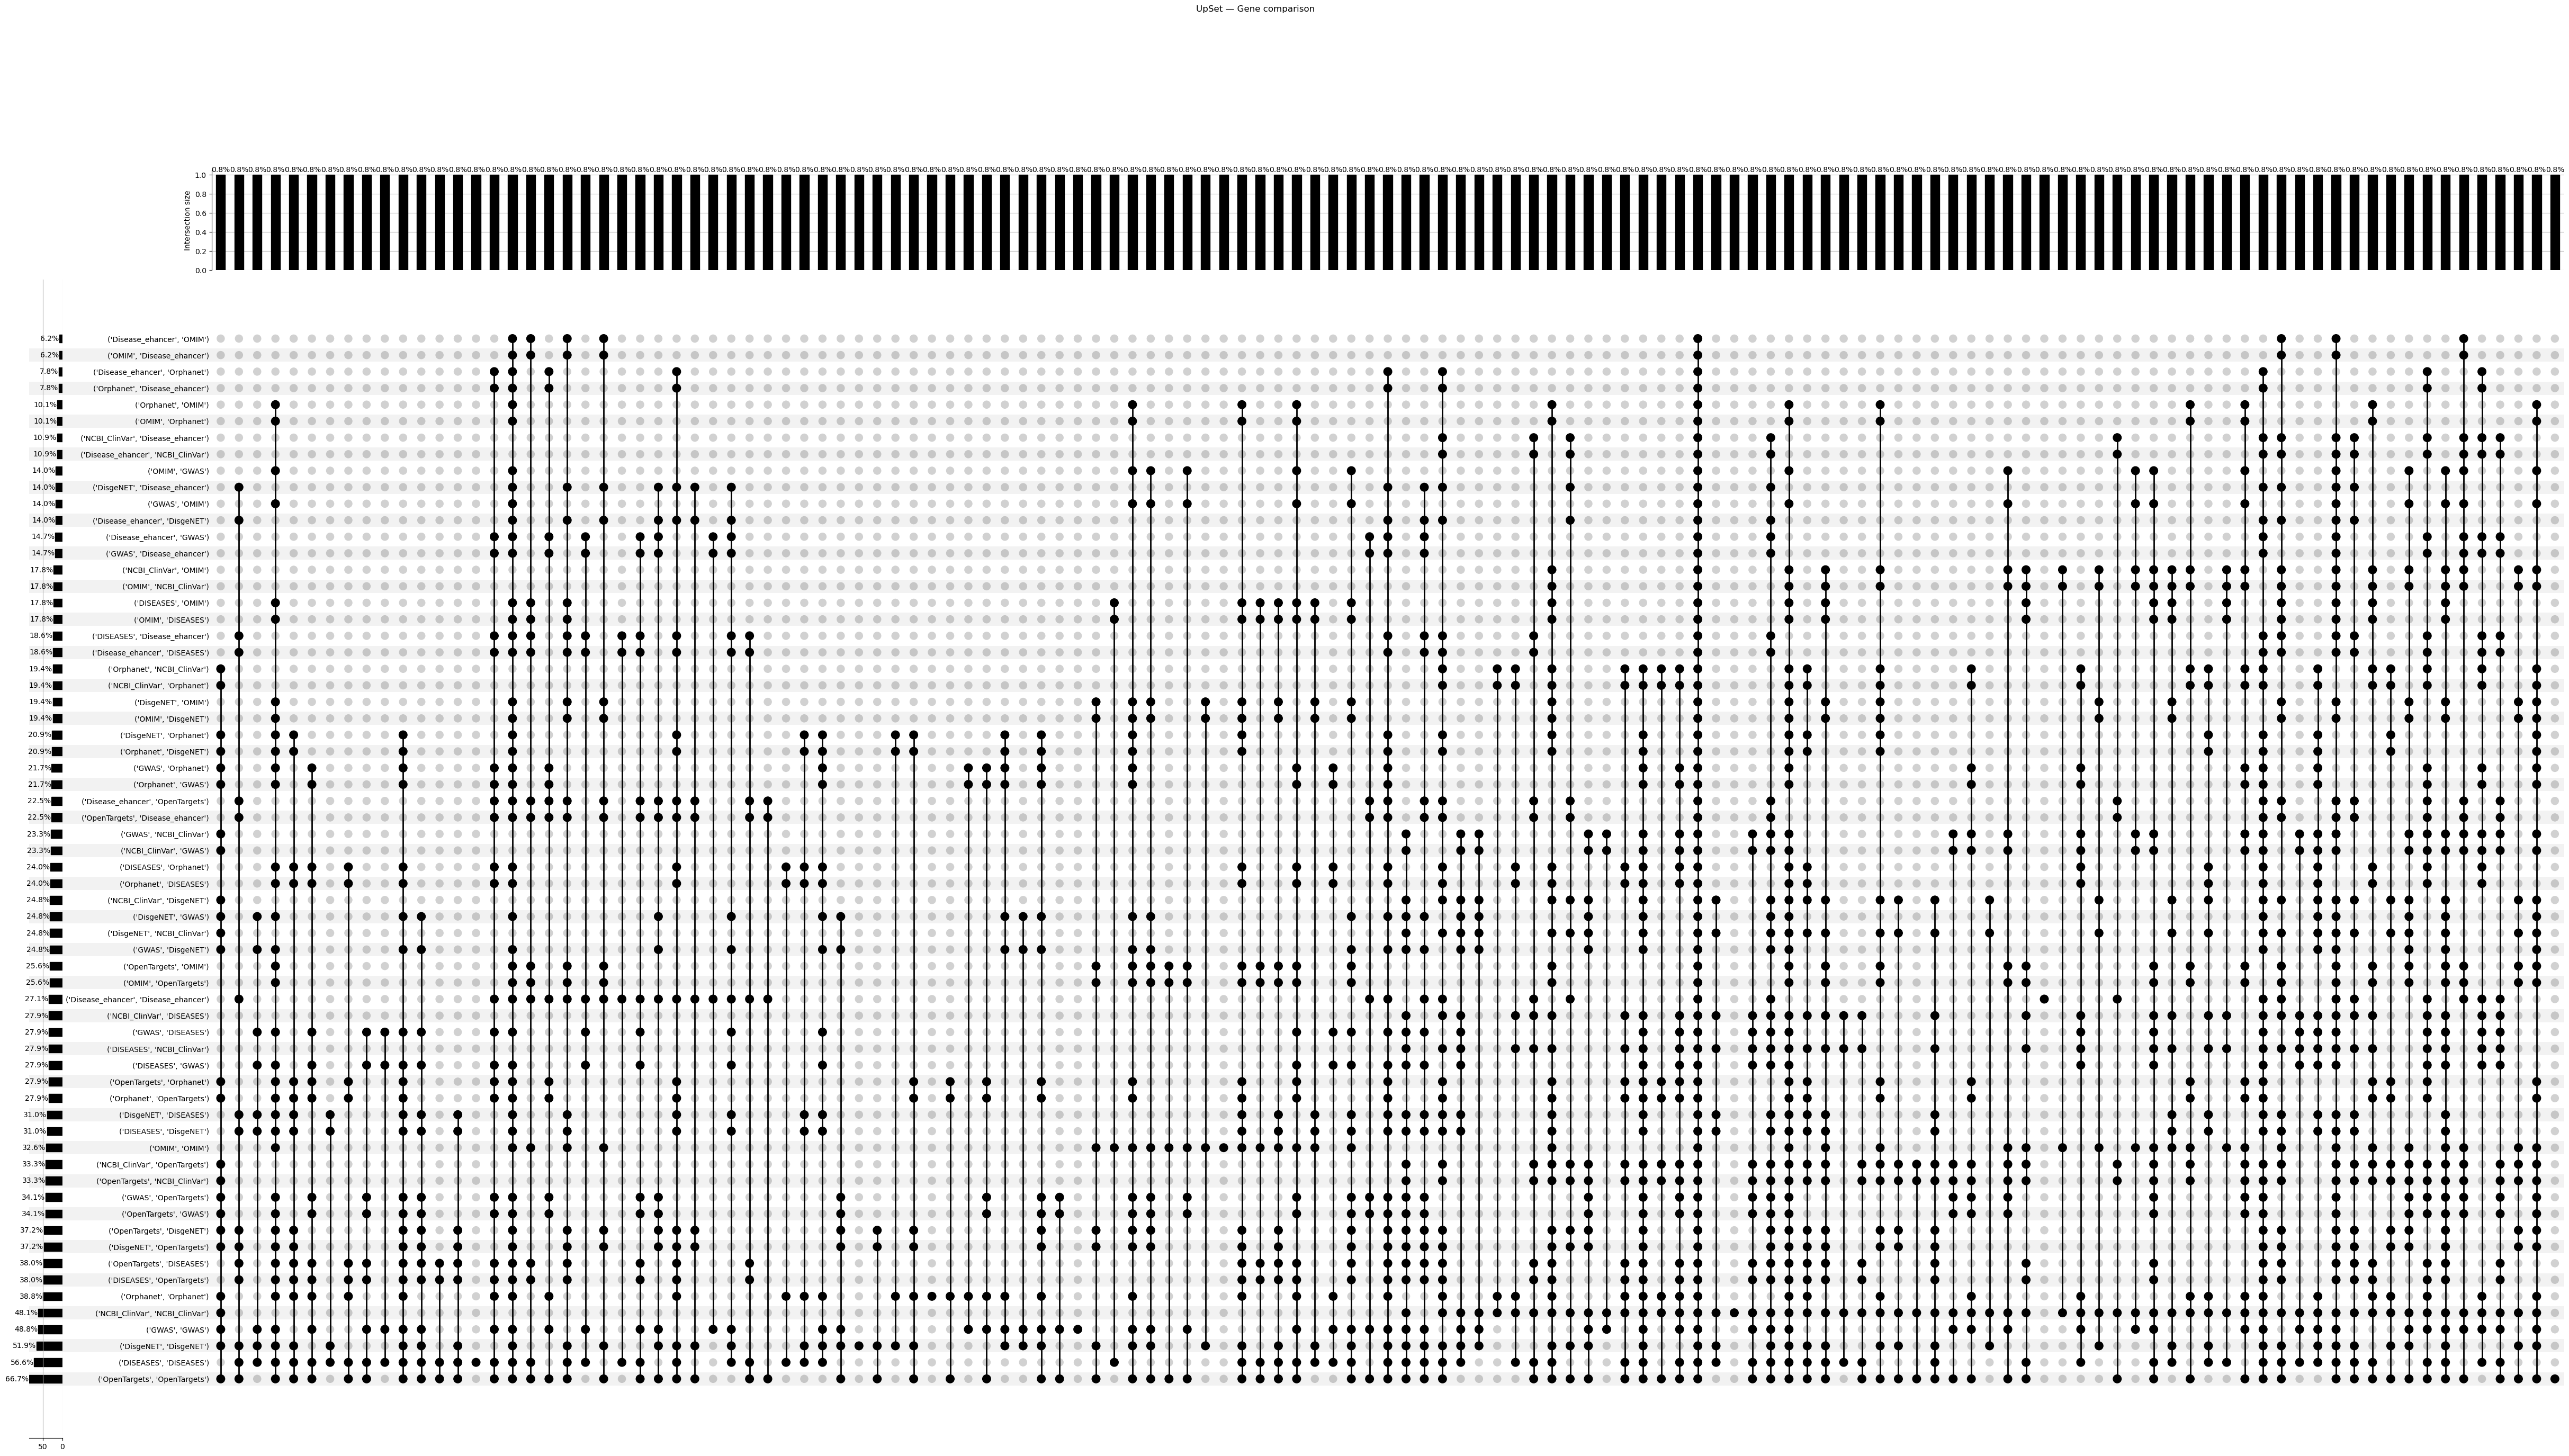

In [29]:
# upset_from_pickles_robust.py
import pickle
from collections import Counter
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_memberships

# Silence a noisy pandas FutureWarning from upsetplot internals
warnings.filterwarnings("ignore", category=FutureWarning)

# --- paths to your files ---
DIS_FILE  = "output/sources_dict_cl_dis_comparison_dict.pickle"
GENE_FILE = "output/sources_dict_cl_gene_comparison_dict.pickle"

# ---------- IO ----------
def load_pickle(path: str):
    with open(path, "rb") as f:
        return pickle.load(f)

# ---------- normalization helpers ----------
def _is_iterable_but_not_str(x):
    return hasattr(x, "__iter__") and not isinstance(x, (str, bytes))

def normalize_to_item_to_groups(obj) -> dict:
    """
    Return dict: item -> set({group_names})
    Accepts common shapes:
      A) group -> iterable(items)
      B) item  -> iterable(groups)
      C) nested dicts with truthy flags:
           - group -> dict(item -> truthy)
           - item  -> dict(group -> truthy)
    Raises ValueError if structure can't be inferred.
    """
    if not isinstance(obj, dict) or not obj:
        raise ValueError("Expected a non-empty dict at top level.")

    k0, v0 = next(iter(obj.items()))

    # A) group -> iterable(items)
    if _is_iterable_but_not_str(v0) and not isinstance(v0, dict):
        item_to_groups = {}
        for group, items in obj.items():
            if not _is_iterable_but_not_str(items) or isinstance(items, dict):
                continue
            gname = str(group)
            for it in items:
                item_to_groups.setdefault(it, set()).add(gname)
        if item_to_groups:
            return item_to_groups

    # B) item -> iterable(groups)
    if _is_iterable_but_not_str(v0) and not isinstance(v0, dict):
        # Could also be case A), already handled. Try B) explicitly:
        item_to_groups = {}
        ok = True
        for item, groups in obj.items():
            if not _is_iterable_but_not_str(groups) or isinstance(groups, dict):
                ok = False
                break
            item_to_groups[item] = set(map(str, groups))
        if ok and item_to_groups:
            return item_to_groups

    # C) dicts of dicts with flags
    if isinstance(v0, dict):
        # Try: group -> dict(item -> truthy)
        item_to_groups = {}
        for group, sub in obj.items():
            if not isinstance(sub, dict):
                item_to_groups = {}
                break
            for it, val in sub.items():
                if bool(val):
                    item_to_groups.setdefault(it, set()).add(str(group))
        if item_to_groups:
            return item_to_groups

        # Try: item -> dict(group -> truthy)
        item_to_groups = {}
        for it, sub in obj.items():
            if not isinstance(sub, dict):
                item_to_groups = {}
                break
            for group, val in sub.items():
                if bool(val):
                    item_to_groups.setdefault(it, set()).add(str(group))
        if item_to_groups:
            return item_to_groups

    raise ValueError("Could not infer structure. Provide dict of group->items, item->groups, or dicts with truthy flags.")

def make_boolean_df(item_to_groups: dict) -> pd.DataFrame:
    """Rows = items, Cols = groups, dtype=bool."""
    all_groups = sorted({g for s in item_to_groups.values() for g in s})
    if not all_groups:
        raise ValueError("No groups found after normalization.")
    rows = []
    idx  = []
    for item, groups in item_to_groups.items():
        rows.append([g in groups for g in all_groups])
        idx.append(item)
    df = pd.DataFrame(rows, index=pd.Index(idx, name="item"), columns=all_groups, dtype=bool)
    # Drop all-false rows (no membership)
    df = df[df.any(axis=1)]
    if df.empty:
        raise ValueError("All rows are empty after filtering (no memberships).")
    return df

# ---------- plotting ----------
def plot_upset(df: pd.DataFrame, title: str = None, save_path: str = None):
    """
    Builds memberships from boolean DF, aggregates duplicates, plots UpSet.
    This avoids upsetplot's 'subset_size=\"auto\" with non-unique groups' error.
    """
    # Build memberships per item/row
    memberships = []
    cols = list(df.columns)
    for row in df.itertuples(index=False, name=None):
        active = tuple(c for c, present in zip(cols, row) if present)
        if active:
            memberships.append(active)
    if not memberships:
        raise ValueError("No memberships found (all rows false).")

    # Aggregate identical memberships -> counts
    counts = Counter(memberships)
    uniq_memberships = list(counts.keys())
    weights = np.array([counts[m] for m in uniq_memberships], dtype=int)

    # Create Series with explicit counts (unique index)
    data = from_memberships(uniq_memberships, data=weights)

    # Plot
    plt.figure(figsize=(10, 6))
    upset = UpSet(
        data,
        sort_by="cardinality",
        show_percentages=True,
        subset_size="count"  # explicit counts, avoids 'auto' pitfall
    )
    upset.plot()
    if title:
        plt.suptitle(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")
    plt.show()

def run_one(path: str, title: str, out_png: str, out_csv: str):
    obj = load_pickle(path)
    item_to_groups = normalize_to_item_to_groups(obj)
    df = make_boolean_df(item_to_groups)
    # Optional: drop empty columns if any slipped through
    df = df.loc[:, df.any(axis=0)]
    if df.shape[1] == 0:
        raise ValueError("No non-empty groups after filtering.")
    # Save matrix for inspection
    df.astype(int).to_csv(out_csv)
    print(f"Wrote matrix: {out_csv} (rows={df.shape[0]}, cols={df.shape[1]})")
    plot_upset(df, title=title, save_path=out_png)
    return df

if __name__ == "__main__":
    # 1) Diseases
    run_one(
        DIS_FILE,
        title   ="UpSet — Disease comparison",
        out_png ="upset_disease.png",
        out_csv ="upset_disease_matrix.csv"
    )

    # 2) Genes
    run_one(
        GENE_FILE,
        title   ="UpSet — Gene comparison",
        out_png ="upset_gene.png",
        out_csv ="upset_gene_matrix.csv"
    )



In [31]:
import pickle
from pprint import pprint

DIS_FILE  = "output/sources_dict_cl_dis_comparison_dict.pickle"
GENE_FILE = "output/sources_dict_cl_gene_comparison_dict.pickle"

def py_str_like(path, max_items=5):
    with open(path, "rb") as f:
        obj = pickle.load(f)
    print(f"=== {path} ===")
    print(f"Type: {type(obj)}")
    try:
        print(f"Length: {len(obj)}")
    except Exception:
        pass

    if isinstance(obj, dict):
        keys = list(obj.keys())
        print(f"First {min(max_items, len(keys))} keys:")
        for k in keys[:max_items]:
            print(f"  {repr(k)} -> type={type(obj[k])}, value preview={repr(obj[k])[:80]}")
    elif isinstance(obj, (list, tuple, set)):
        print(f"First {min(max_items, len(obj))} elements:")
        for el in list(obj)[:max_items]:
            print(f"  type={type(el)}, value preview={repr(el)[:80]}")
    else:
        pprint(obj)

# Run
py_str_like(DIS_FILE)
py_str_like(GENE_FILE)



=== output/sources_dict_cl_dis_comparison_dict.pickle ===
Type: <class 'dict'>
Length: 64
First 5 keys:
  ('NCBI_ClinVar', 'NCBI_ClinVar') -> type=<class 'set'>, value preview={'P70', 'Q44', 'C97', 'Q74', 'M24', 'E20', 'Q51', 'B06', 'Q41', 'Q13', 'P76', 'E
  ('NCBI_ClinVar', 'Disease_ehancer') -> type=<class 'set'>, value preview={'I48', 'C14', 'D66', 'I72', 'D44', 'J44', 'A30', 'E80', 'C92', 'M05', 'Q35', 'Q
  ('NCBI_ClinVar', 'DISEASES') -> type=<class 'set'>, value preview={'P70', 'Q44', 'C97', 'Q74', 'M24', 'Q51', 'Q13', 'E83', 'D18', 'D89', 'H54', 'M
  ('NCBI_ClinVar', 'OMIM') -> type=<class 'set'>, value preview={'C97', 'Q44', 'Q74', 'M24', 'Q51', 'Q13', 'E83', 'M91', 'Q18', 'Q99', 'E06', 'M
  ('NCBI_ClinVar', 'GWAS') -> type=<class 'set'>, value preview={'D50', 'L64', 'I48', 'Q44', 'K80', 'D44', 'N13', 'L41', 'A30', 'L10', 'N10', 'Q
=== output/sources_dict_cl_gene_comparison_dict.pickle ===
Type: <class 'dict'>
Length: 64
First 5 keys:
  ('NCBI_ClinVar', 'NCBI_ClinVar') -> type=

In [33]:
import pickle

DIS_FILE  = "output/sources_dict_cl_dis_comparison_dict.pickle"
GENE_FILE = "output/sources_dict_cl_gene_comparison_dict.pickle"

def unique_keys(path):
    with open(path, "rb") as f:
        obj = pickle.load(f)
    if not isinstance(obj, dict):
        raise TypeError(f"{path} does not contain a dict (found {type(obj)})")
    keys = set(obj.keys())
    print(f"=== {path} ===")
    print(f"Total unique keys: {len(keys)}")
    print(keys)

# Run
unique_keys(DIS_FILE)
unique_keys(GENE_FILE)


=== output/sources_dict_cl_dis_comparison_dict.pickle ===
Total unique keys: 64
{('GWAS', 'DISEASES'), ('OMIM', 'DISEASES'), ('DisgeNET', 'Orphanet'), ('DISEASES', 'Orphanet'), ('NCBI_ClinVar', 'NCBI_ClinVar'), ('DISEASES', 'NCBI_ClinVar'), ('DISEASES', 'Disease_ehancer'), ('DisgeNET', 'NCBI_ClinVar'), ('Disease_ehancer', 'Orphanet'), ('Disease_ehancer', 'Disease_ehancer'), ('Disease_ehancer', 'NCBI_ClinVar'), ('NCBI_ClinVar', 'Orphanet'), ('NCBI_ClinVar', 'Disease_ehancer'), ('DisgeNET', 'Disease_ehancer'), ('OpenTargets', 'NCBI_ClinVar'), ('OpenTargets', 'Orphanet'), ('OpenTargets', 'Disease_ehancer'), ('Orphanet', 'Orphanet'), ('Orphanet', 'Disease_ehancer'), ('Orphanet', 'NCBI_ClinVar'), ('GWAS', 'Orphanet'), ('GWAS', 'NCBI_ClinVar'), ('NCBI_ClinVar', 'OMIM'), ('DISEASES', 'OMIM'), ('OMIM', 'Orphanet'), ('OMIM', 'NCBI_ClinVar'), ('DisgeNET', 'OMIM'), ('GWAS', 'Disease_ehancer'), ('Disease_ehancer', 'OMIM'), ('DisgeNET', 'OpenTargets'), ('DISEASES', 'OpenTargets'), ('OMIM', 'Disease

Wrote intersections: upset_disease_intersections_agg.csv
Wrote matrix: upset_disease_matrix_full.csv (rows=1027, cols=64)


/var/folders/v7/09hywxp12yd031lcbmyzz46r0000gp/T/ipykernel_69200/1776497462.py:157: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: upset_disease_agg.png


<Figure size 1000x600 with 0 Axes>

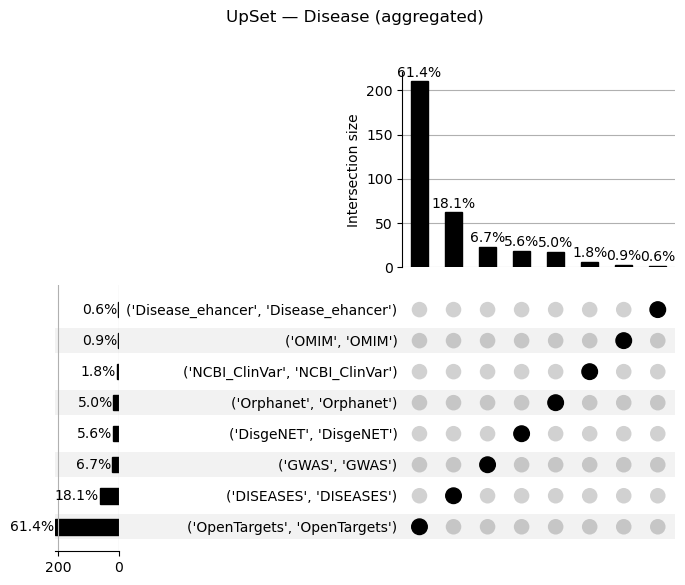

Wrote intersections: upset_gene_intersections_agg.csv
Wrote matrix: upset_gene_matrix_full.csv (rows=18830, cols=64)
Saved: upset_gene_agg.png


/var/folders/v7/09hywxp12yd031lcbmyzz46r0000gp/T/ipykernel_69200/1776497462.py:157: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1000x600 with 0 Axes>

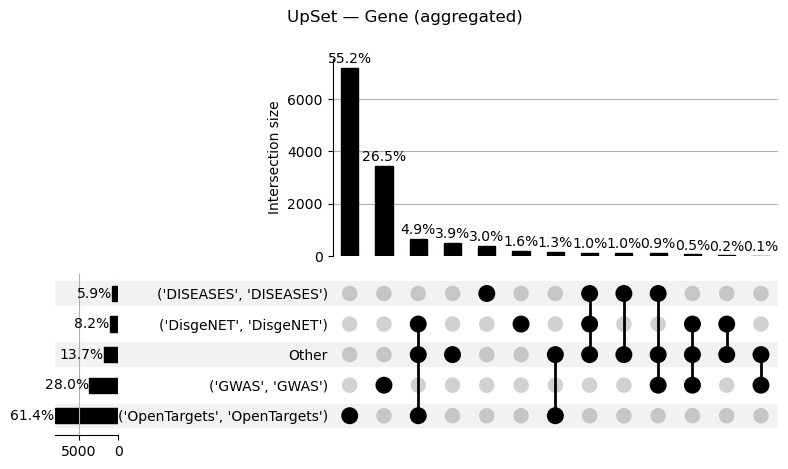

In [41]:
# upset_aggregated_safe.py
import pickle
from collections import Counter
from typing import Callable, Tuple, List, Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_indicators

# ---- files ----
DIS_FILE  = "output/sources_dict_cl_dis_comparison_dict.pickle"
GENE_FILE = "output/sources_dict_cl_gene_comparison_dict.pickle"

# ---- IO / normalize ----
def load_pickle(path: str):
    with open(path, "rb") as f:
        return pickle.load(f)

def _is_iterable_but_not_str(x):
    return hasattr(x, "__iter__") and not isinstance(x, (str, bytes))

def normalize_to_item_to_groups(obj) -> Dict[object, set]:
    if not isinstance(obj, dict) or not obj:
        raise ValueError("Top-level object must be a non-empty dict.")
    _, v0 = next(iter(obj.items()))

    # group -> iterable(items)
    if _is_iterable_but_not_str(v0) and not isinstance(v0, dict):
        out = {}
        for group, items in obj.items():
            if _is_iterable_but_not_str(items) and not isinstance(items, dict):
                g = str(group)
                for it in items:
                    out.setdefault(it, set()).add(g)
        if out: return out

    # item -> iterable(groups)
    ok, out = True, {}
    if _is_iterable_but_not_str(v0) and not isinstance(v0, dict):
        for item, groups in obj.items():
            if not _is_iterable_but_not_str(groups) or isinstance(groups, dict):
                ok = False; break
            out[item] = set(map(str, groups))
        if ok and out: return out

    # dicts with flags
    if isinstance(v0, dict):
        out = {}
        # group -> dict(item -> truthy)
        group_first = True
        for group, sub in obj.items():
            if not isinstance(sub, dict): group_first = False; break
            for it, val in sub.items():
                if bool(val): out.setdefault(it, set()).add(str(group))
        if group_first and out: return out

        # item -> dict(group -> truthy)
        out = {}
        for it, sub in obj.items():
            if not isinstance(sub, dict): out={}; break
            for group, val in sub.items():
                if bool(val): out.setdefault(it, set()).add(str(group))
        if out: return out

    raise ValueError("Unrecognized structure.")

def boolean_df(item_to_groups: Dict[object, set]) -> pd.DataFrame:
    groups = sorted({g for s in item_to_groups.values() for g in s})
    if not groups: raise ValueError("No groups found.")
    rows, idx = [], []
    for item, gset in item_to_groups.items():
        rows.append([g in gset for g in groups])
        idx.append(item)
    df = pd.DataFrame(rows, index=pd.Index(idx, name="item"), columns=groups, dtype=bool)
    df = df[df.any(axis=1)]
    if df.empty: raise ValueError("All rows are empty after filtering (no memberships).")
    return df

# ---- memberships / aggregation ----
def df_to_membership_counts(df: pd.DataFrame) -> Tuple[List[Tuple[str, ...]], np.ndarray]:
    memberships = []
    cols = list(df.columns)
    for row in df.itertuples(index=False, name=None):
        active = tuple(c for c, present in zip(cols, row) if present)
        if active: memberships.append(active)
    if not memberships: raise ValueError("No memberships found.")
    counts = Counter(memberships)
    uniq = list(counts.keys())
    w = np.array([counts[m] for m in uniq], dtype=int)
    return uniq, w

def aggregate_memberships(
    memberships: List[Tuple[str, ...]],
    weights: np.ndarray,
    *,
    top_groups: Optional[int] = 8,
    min_group_count: Optional[int] = None,
    group_func: Optional[Callable[[str], str]] = None,
    collapse_other: bool = True,
    max_degree: Optional[int] = 3,
    top_intersections: Optional[int] = 25,
    min_intersection_weight: Optional[int] = None,
) -> Tuple[List[Tuple[str, ...]], np.ndarray]:
    # Optional mapping/bucketing
    if group_func is not None:
        mapped = [tuple(sorted({group_func(g) for g in m})) for m in memberships]
        memberships = [mm for mm in mapped if mm]

    # Group totals (weighted)
    group_totals = Counter()
    for m, w in zip(memberships, weights):
        for g in set(m): group_totals[g] += int(w)

    kept = set(group_totals.keys())
    if min_group_count is not None:
        kept = {g for g in kept if group_totals[g] >= min_group_count}
    if top_groups is not None and len(kept) > top_groups:
        kept = set([g for g, _ in group_totals.most_common(top_groups)])

    OTHER = "Other"
    new_counts = Counter()
    for m, w in zip(memberships, weights):
        mapped_groups = [(g if g in kept else OTHER) if collapse_other else g for g in m]
        mg = tuple(sorted(set(mapped_groups)))
        if not mg: continue
        if max_degree is not None and len(mg) > max_degree: continue
        new_counts[mg] += int(w)

    if min_intersection_weight is not None:
        new_counts = Counter({k:v for k,v in new_counts.items() if v >= min_intersection_weight})
    if top_intersections is not None and len(new_counts) > top_intersections:
        new_counts = Counter(dict(new_counts.most_common(top_intersections)))

    uniq = list(new_counts.keys())
    w = np.array([new_counts[m] for m in uniq], dtype=int)
    return uniq, w

# ---- plotting ----
def memberships_to_indicator_df(uniq_memberships, weights) -> pd.DataFrame:
    cats = sorted({g for m in uniq_memberships for g in m})
    rows = []
    for m, w in zip(uniq_memberships, weights):
        row = {c: (c in m) for c in cats}
        row["weight"] = int(w)
        rows.append(row)
    df = pd.DataFrame(rows)
    for c in cats: df[c] = df[c].astype(bool)
    return df, cats

def plot_upset_weighted(df_ind: pd.DataFrame, title=None, save_path=None):
    series = from_indicators(df_ind.drop(columns=["weight"]), data=df_ind["weight"])
    plt.figure(figsize=(10,6))
    upset = UpSet(series, subset_size="sum", sort_by="cardinality", show_percentages=True)
    upset.plot()
    if title: plt.suptitle(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight"); print(f"Saved: {save_path}")
    plt.show()

def fallback_barplot(group_totals: Counter, title: str, save_path: Optional[str] = None, top_n: int = 15):
    items = group_totals.most_common(top_n)
    if not items:
        raise ValueError("Nothing to plot in fallback.")
    labels, vals = zip(*items)
    plt.figure(figsize=(10,6))
    plt.barh(range(len(vals)), vals)
    plt.yticks(range(len(vals)), labels)
    plt.xlabel("Count"); plt.title(f"{title} — Group totals (fallback)")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    if save_path:
        sp = save_path.replace(".png", "_fallback.png")
        plt.savefig(sp, dpi=300, bbox_inches="tight"); print(f"Saved: {sp}")
    plt.show()

# ---- bucketizers ----
def icd_first_letter(ch: str) -> str:
    return (ch[0] if ch and isinstance(ch, str) else str(ch))

# ---- driver with auto-relax ----
def run_one(path: str, title: str, out_png: str, out_csv_matrix: str, out_csv_intersections: str,
            use_group_func: bool = True):
    obj = load_pickle(path)
    item_to_groups = normalize_to_item_to_groups(obj)
    df = boolean_df(item_to_groups)

    uniq, w = df_to_membership_counts(df)

    # Start with stricter aggregation
    params = dict(
        top_groups=8,
        min_group_count=None,
        group_func=(icd_first_letter if use_group_func else None),
        collapse_other=True,
        max_degree=3,
        top_intersections=25,
        min_intersection_weight=None,
    )

    # Try, and auto-relax until we have ≥2 categories
    for step in range(5):
        uniq_small, w_small = aggregate_memberships(uniq, w, **params)
        df_ind, cats = memberships_to_indicator_df(uniq_small, w_small)
        n_cats = len([c for c in df_ind.columns if c != "weight"])
        if n_cats >= 2 and len(df_ind) > 0:
            # Save artifacts
            pd.DataFrame({"membership":[",".join(m) for m in uniq_small],"count":w_small})\
              .sort_values("count", ascending=False).to_csv(out_csv_intersections, index=False)
            print(f"Wrote intersections: {out_csv_intersections}")
            df.astype(int).to_csv(out_csv_matrix)
            print(f"Wrote matrix: {out_csv_matrix} (rows={df.shape[0]}, cols={df.shape[1]})")
            # Plot
            plot_upset_weighted(df_ind, title=title, save_path=out_png)
            return

        # Relax strategy
        if step == 0:
            params["top_groups"] = None  # allow all groups
        elif step == 1:
            params["collapse_other"] = False
        elif step == 2:
            params["group_func"] = None  # turn off bucketing
        elif step == 3:
            params["max_degree"] = None  # allow higher-order intersections

    # Final fallback: bar chart of group totals
    print("UpSet unsuitable (ended with <2 categories). Falling back to bar chart of group totals.")
    # compute totals from raw df
    totals = Counter({c: int(df[c].sum()) for c in df.columns})
    fallback_barplot(totals, title, save_path=out_png, top_n=15)

if __name__ == "__main__":
    # Diseases
    run_one(
        DIS_FILE,
        title="UpSet — Disease (aggregated)",
        out_png="upset_disease_agg.png",
        out_csv_matrix="upset_disease_matrix_full.csv",
        out_csv_intersections="upset_disease_intersections_agg.csv",
        use_group_func=True
    )

    # Genes
    run_one(
        GENE_FILE,
        title="UpSet — Gene (aggregated)",
        out_png="upset_gene_agg.png",
        out_csv_matrix="upset_gene_matrix_full.csv",
        out_csv_intersections="upset_gene_intersections_agg.csv",
        use_group_func=False
    )


In [79]:
import numpy as np
import pandas as pd
from itertools import chain

# --- 1) Clean sources_dict -> sources_dict_cl ---
def is_valid_gene(g):
    # filters out None/NaN-like values without needing pandas
    return g is not None and g == g and str(g).lower() != "nan"

sources_dict_cl = {}
for source, disdict in sources_dict.items():
    n_disdict = {}
    for dis, genes in disdict.items():
        if genes:
            clean_genes = [g for g in genes if is_valid_gene(g)]
            if clean_genes:
                n_disdict[dis] = clean_genes
    sources_dict_cl[source] = n_disdict

# If you *must* force exactly 8 sources in a fixed order, pick them here:
# sources_order = list(sources_dict_cl.keys())[:8]
sources_order = list(sources_dict_cl.keys())

# --- 2) Build per-source sets ---
disease_sets = {s: set(disdict.keys()) for s, disdict in sources_dict_cl.items()}
gene_sets    = {s: set(chain.from_iterable(disdict.values())) for s, disdict in sources_dict_cl.items()}

# --- 3) Fill overlap matrices ---
n = len(sources_order)
dis_mat = np.zeros((n, n), dtype=int)
gene_mat = np.zeros((n, n), dtype=int)

for i, s1 in enumerate(sources_order):
    for j, s2 in enumerate(sources_order):
        dis_mat[i, j]  = len(disease_sets[s1] & disease_sets[s2])
        gene_mat[i, j] = len(gene_sets[s1] & gene_sets[s2])

# --- 4) Wrap as DataFrames for readability & save ---
dis_overlap_df  = pd.DataFrame(dis_mat, index=sources_order, columns=sources_order)
gene_overlap_df = pd.DataFrame(gene_mat, index=sources_order, columns=sources_order)

print("Disease overlap matrix:")
print(dis_overlap_df)

print("\nGene overlap matrix:")
print(gene_overlap_df)

# Save
dis_overlap_df.to_csv("output/disease_overlap_matrix.csv")
gene_overlap_df.to_csv("output/gene_overlap_matrix.csv")


Disease overlap matrix:
                 NCBI_ClinVar  Disease_ehancer  DISEASES  OMIM  GWAS  \
NCBI_ClinVar              187               27       130    80    45   
Disease_ehancer            27               81        51    15    30   
DISEASES                  130               51       463    87   110   
OMIM                       80               15        87   132    29   
GWAS                       45               30       110    29   282   
Orphanet                  121               33       177    71    72   
DisgeNET                  125               43       215    79   102   
OpenTargets               120               62       283    83   212   

                 Orphanet  DisgeNET  OpenTargets  
NCBI_ClinVar          121       125          120  
Disease_ehancer        33        43           62  
DISEASES              177       215          283  
OMIM                   71        79           83  
GWAS                   72       102          212  
Orphanet             


=== Disease ===
Requested → Used column mapping:
        NCBI_ClinVar  ->  ('OMIM', 'NCBI_ClinVar')
     Disease_ehancer  ->  ('OMIM', 'Disease_ehancer')
            DISEASES  ->  ('OMIM', 'DISEASES')
                OMIM  ->  ('OMIM', 'OMIM')
                GWAS  ->  ('OMIM', 'GWAS')
            Orphanet  ->  ('Orphanet', 'OMIM')
            DisgeNET  ->  ('OMIM', 'DisgeNET')
         OpenTargets  ->  ('OpenTargets', 'OMIM')


/var/folders/v7/09hywxp12yd031lcbmyzz46r0000gp/T/ipykernel_69200/916278781.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sub[c] = df_sub[c].astype(bool)
/var/folders/v7/09hywxp12yd031lcbmyzz46r0000gp/T/ipykernel_69200/916278781.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sub[c] = df_sub[c].astype(bool)
/var/folders/v7/09hywxp12yd031lcbmyzz46r0000gp/T/ipykernel_69200/916278781.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

Saved: upset_disease_8db.png


<Figure size 1000x600 with 0 Axes>

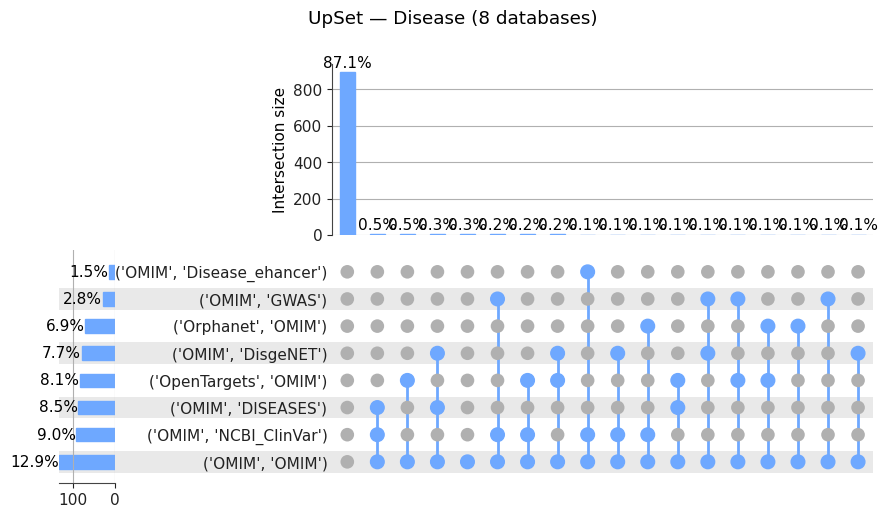


=== Gene ===
Requested → Used column mapping:
        NCBI_ClinVar  ->  ('OMIM', 'NCBI_ClinVar')
     Disease_ehancer  ->  ('OMIM', 'Disease_ehancer')
            DISEASES  ->  ('OMIM', 'DISEASES')
                OMIM  ->  ('OMIM', 'OMIM')
                GWAS  ->  ('OMIM', 'GWAS')
            Orphanet  ->  ('Orphanet', 'OMIM')
            DisgeNET  ->  ('OMIM', 'DisgeNET')
         OpenTargets  ->  ('OpenTargets', 'OMIM')


/var/folders/v7/09hywxp12yd031lcbmyzz46r0000gp/T/ipykernel_69200/916278781.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sub[c] = df_sub[c].astype(bool)
/var/folders/v7/09hywxp12yd031lcbmyzz46r0000gp/T/ipykernel_69200/916278781.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sub[c] = df_sub[c].astype(bool)
/var/folders/v7/09hywxp12yd031lcbmyzz46r0000gp/T/ipykernel_69200/916278781.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .l

Saved: upset_gene_8db.png


<Figure size 1000x600 with 0 Axes>

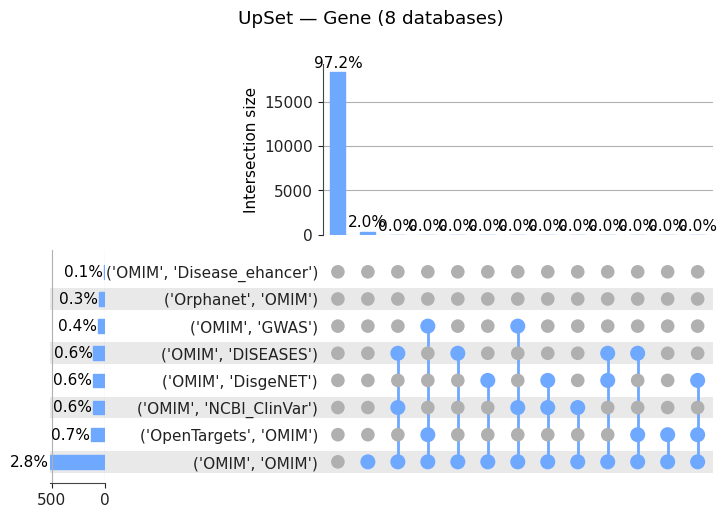

In [57]:
# upset_8db_fuzzy.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from difflib import get_close_matches
from upsetplot import UpSet, from_indicators

DIS_CSV  = "upset_disease_matrix_full.csv"
GENE_CSV = "upset_gene_matrix_full.csv"

REQUESTED_DB_LABELS = [
    "NCBI_ClinVar",
    "Disease_ehancer",   # will fuzzy-match even if spelled differently
    "DISEASES",
    "OMIM",
    "GWAS",
    "Orphanet",
    "DisgeNET",
    "OpenTargets",
]

def canonical(s: str) -> str:
    # lower, keep only alnum, collapse
    return "".join(ch for ch in s.lower() if ch.isalnum())

def load_bool_matrix(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, index_col=0)
    # Force boolean
    for c in df.columns:
        # accept 0/1, '0'/'1', True/False
        vals = df[c]
        if vals.dtype == bool:
            continue
        if pd.api.types.is_numeric_dtype(vals):
            df[c] = vals.astype(int).astype(bool)
        else:
            df[c] = vals.astype(str).str.strip().str.lower().map({"true": True, "false": False, "1": True, "0": False})
            if df[c].isna().any():
                # fallback: anything nonzero numeric -> True
                try:
                    df[c] = pd.to_numeric(vals, errors="coerce").fillna(0).astype(int).astype(bool)
                except Exception:
                    df[c] = df[c].fillna(False).astype(bool)
    # drop empty columns/rows
    df = df.loc[:, df.any(axis=0)]
    df = df.loc[df.any(axis=1)]
    return df

def map_requested_to_columns(df: pd.DataFrame, requested_labels):
    # Build canonical -> original map for existing columns
    existing = list(df.columns)
    canon_to_orig = {}
    for col in existing:
        canon_to_orig.setdefault(canonical(col), col)

    mapping = {}
    not_found = []
    for label in requested_labels:
        key = canonical(label)
        if key in canon_to_orig:
            mapping[label] = canon_to_orig[key]
            continue
        # fuzzy match among existing canonical keys
        candidates = list(canon_to_orig.keys())
        close = get_close_matches(key, candidates, n=1, cutoff=0.6)
        if close:
            mapping[label] = canon_to_orig[close[0]]
        else:
            not_found.append(label)

    return mapping, not_found

def build_series_for_upset(df_bool: pd.DataFrame, cols_in_order):
    # Keep only requested columns that exist, in the given order
    cols = [c for c in cols_in_order if c in df_bool.columns]
    if len(cols) < 2:
        raise ValueError(f"Need at least 2 matched columns, got {len(cols)}.")
    df_sub = df_bool[cols]
    # must have pure bool dtype
    for c in cols:
        df_sub[c] = df_sub[c].astype(bool)
    series = from_indicators(df_sub)
    return series, cols

def plot_upset_fixed(series, title, outfile, max_degree=3, max_subsets=25):
    plt.figure(figsize=(10, 6))
    upset = UpSet(
        series,
        sort_by="cardinality",
        subset_size="count",
        show_percentages=True,
        max_degree=max_degree,
        max_subset_rank=max_subsets,
        facecolor="#6EA8FF",
        other_dots_color="#B0B0B0",
        shading_color="#E9E9E9",
        with_lines=True,
        element_size=28
    )
    upset.plot()
    plt.suptitle(title, y=0.98)
    plt.tight_layout()
    plt.savefig(outfile, dpi=300, bbox_inches="tight")
    print(f"Saved: {outfile}")
    plt.show()

def run_one(csv_path, label):
    df = load_bool_matrix(csv_path)
    mapping, missing = map_requested_to_columns(df, REQUESTED_DB_LABELS)

    print(f"\n=== {label} ===")
    print("Requested → Used column mapping:")
    for req in REQUESTED_DB_LABELS:
        used = mapping.get(req, None)
        print(f"  {req:>18}  ->  {used if used else 'NOT FOUND'}")
    if missing:
        print(f"WARNING: {len(missing)} requested columns not found: {missing}")

    used_cols = [mapping[k] for k in REQUESTED_DB_LABELS if k in mapping]
    series, cols_used = build_series_for_upset(df, used_cols)
    outname = f"upset_{label.lower()}_8db.png"
    plot_upset_fixed(series, f"UpSet — {label} (8 databases)", outname, max_degree=3, max_subsets=30)

if __name__ == "__main__":
    run_one(DIS_CSV, "Disease")
    run_one(GENE_CSV, "Gene")



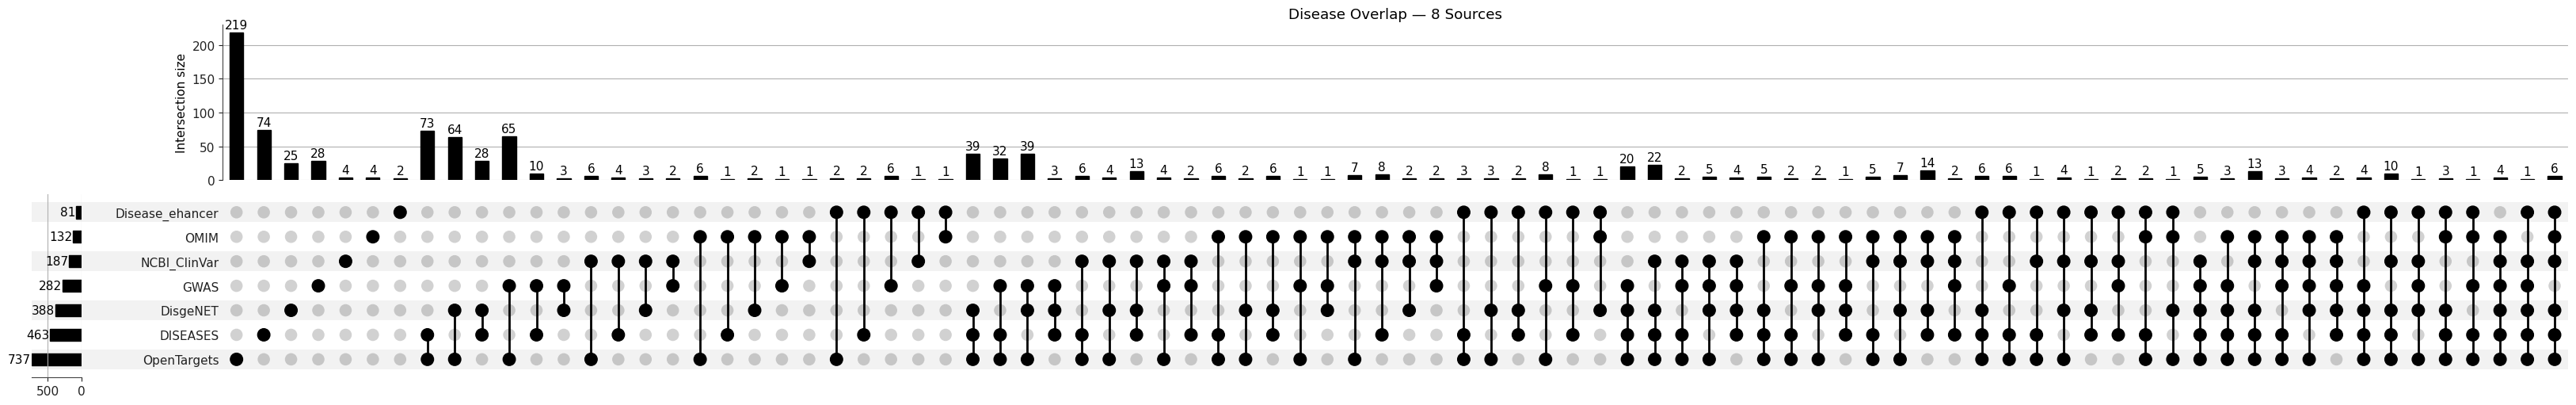

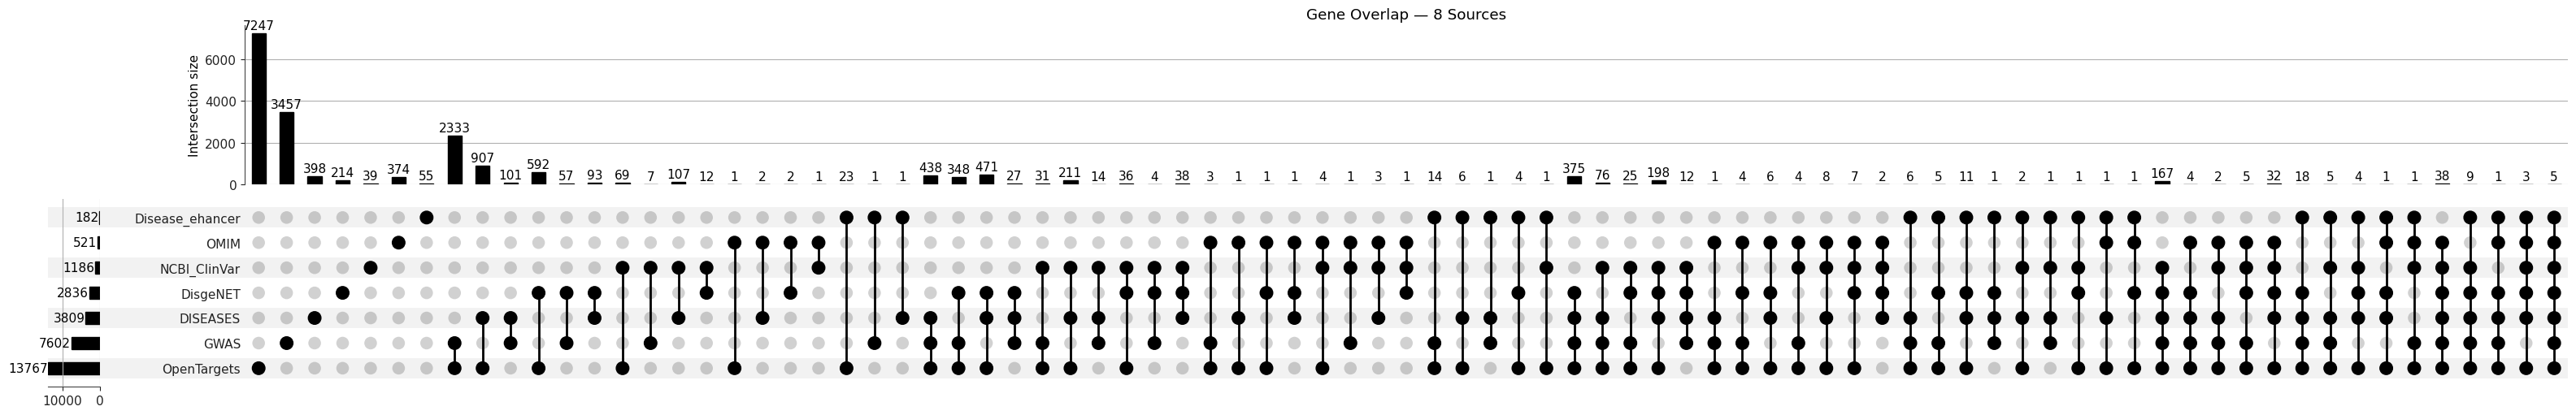

In [59]:
import pandas as pd
from itertools import chain
from upsetplot import UpSet, from_memberships
import matplotlib.pyplot as plt

# --- pick 8 sources ---
sources_order = list(sources_dict_cl.keys())[:8]  # force first 8

# --- disease sets ---
disease_sets = {s: set(disdict.keys()) for s, disdict in sources_dict_cl.items() if s in sources_order}

# --- gene sets ---
gene_sets = {s: set(chain.from_iterable(disdict.values())) for s, disdict in sources_dict_cl.items() if s in sources_order}

# Function to create memberships list for upsetplot
def make_memberships(sets_dict):
    memberships = []
    for label, items in sets_dict.items():
        memberships.extend([(label, item) for item in items])
    # Create a mapping: item -> list of sets it belongs to
    item_to_sets = {}
    for label, items in sets_dict.items():
        for item in items:
            item_to_sets.setdefault(item, []).append(label)
    return list(item_to_sets.values())

# --- UpSet for diseases ---
disease_memberships = make_memberships(disease_sets)
disease_upset_data = from_memberships(disease_memberships)
UpSet(disease_upset_data, subset_size='count', show_counts=True).plot()
plt.title("Disease Overlap — 8 Sources")
plt.show()

# --- UpSet for genes ---
gene_memberships = make_memberships(gene_sets)
gene_upset_data = from_memberships(gene_memberships)
UpSet(gene_upset_data, subset_size='count', show_counts=True).plot()
plt.title("Gene Overlap — 8 Sources")
plt.show()


In [85]:
import pandas as pd
from itertools import chain
from upsetplot import UpSet, from_memberships
import matplotlib.pyplot as plt

# --- pick exactly 8 sources ---
sources_order = list(sources_dict_cl.keys())[:8]

# --- disease sets ---
disease_sets = {s: set(disdict.keys()) for s, disdict in sources_dict_cl.items() if s in sources_order}

# --- gene sets ---
gene_sets = {s: set(chain.from_iterable(disdict.values())) for s, disdict in sources_dict_cl.items() if s in sources_order}

def make_memberships(sets_dict):
    """Return list of dataset memberships for upsetplot."""
    item_to_sets = {}
    for label, items in sets_dict.items():
        for item in items:
            item_to_sets.setdefault(item, []).append(label)
    return list(item_to_sets.values())

def plot_and_save_upset(memberships, title, out_file):
    data = from_memberships(memberships)
    upset = UpSet(data, subset_size='count', show_counts=True)
    upset.plot()
    plt.title(title)
    plt.gcf().set_size_inches(30, 5)  # width, height in inches
    plt.savefig(out_file, dpi=300, bbox_inches="tight")
    plt.close()

# --- Plot & save ---
plot_and_save_upset(make_memberships(disease_sets),
                    "Disease Overlap — 8 Sources",
                    "disease_overlap_upset.png")

plot_and_save_upset(make_memberships(gene_sets),
                    "Gene Overlap — 8 Sources",
                    "gene_overlap_upset.png")


In [149]:
import pandas as pd
from itertools import chain
from upsetplot import UpSet, from_memberships
import matplotlib.pyplot as plt

# --- exactly 8 sources ---
sources_order = list(sources_dict_cl.keys())[:8]

disease_sets = {s: set(d.keys()) for s, d in sources_dict_cl.items() if s in sources_order}
gene_sets    = {s: set(chain.from_iterable(d.values())) for s, d in sources_dict_cl.items() if s in sources_order}

def make_memberships(sets_dict):
    item_to_sets = {}
    for label, items in sets_dict.items():
        for item in items:
            item_to_sets.setdefault(item, []).append(label)
    return list(item_to_sets.values())

def add_count_labels_only_big(upset, thresh=4):
    # Try to get the top bar axis robustly across upsetplot versions
    top_ax = None
    if hasattr(upset, "ax_dict"):
        top_ax = upset.ax_dict.get("intersections", None)
    if top_ax is None:
        # Fallback: pick the axes with the most rectangle patches (the bar plot)
        axes = plt.gcf().axes
        cand = sorted(axes, key=lambda ax: len(getattr(ax, "patches", [])), reverse=True)
        top_ax = cand[0] if cand else None

    if top_ax is None:
        return  # bail out silently if we can’t find it

    for rect in top_ax.patches:
        h = rect.get_height()
        if h > thresh:
            top_ax.text(
                rect.get_x() + rect.get_width()/2,
                h + 0.5,
                f"{int(h)}",
                ha="center", va="bottom", fontsize=8
            )

def plot_and_save_upset(memberships, title, out_file, max_combination_size=3):
    data = from_memberships(memberships)

    # keep only combinations up to size 3
    mask = [sum(k) <= max_combination_size for k in data.index]
    data_f = data[mask]

    # build plot (turn off default counts; we’ll add conditional labels)
    upset = UpSet(data_f, subset_size="count", show_counts=False, sort_by="cardinality")
    upset.plot()

    add_count_labels_only_big(upset, thresh=4)

    plt.suptitle(title)
    plt.gcf().set_size_inches(30, 5)
    plt.savefig(out_file, dpi=300, bbox_inches="tight")
    plt.close()

# --- run both ---
plot_and_save_upset(make_memberships(disease_sets),
                    "Disease Overlap — ≤3-way",
                    "disease_overlap_upset_max3.png")

plot_and_save_upset(make_memberships(gene_sets),
                    "Gene Overlap — ≤3-way",
                    "gene_overlap_upset_max3.png")



In [137]:
import pandas as pd
from itertools import chain
from upsetplot import UpSet, from_memberships
import matplotlib.pyplot as plt

# --- exactly 8 sources ---
sources_order = list(sources_dict_cl.keys())[:8]
disease_sets = {s: set(d.keys()) for s, d in sources_dict_cl.items() if s in sources_order}
gene_sets    = {s: set(chain.from_iterable(d.values())) for s, d in sources_dict_cl.items() if s in sources_order}

def make_memberships(sets_dict):
    item_to_sets = {}
    for label, items in sets_dict.items():
        for item in items:
            item_to_sets.setdefault(item, []).append(label)
    return list(item_to_sets.values())

def add_count_labels_only_big(upset, thresh=4):
    top_ax = None
    if hasattr(upset, "ax_dict"):
        top_ax = upset.ax_dict.get("intersections", None)
    if top_ax is None:
        axes = plt.gcf().axes
        cand = sorted(axes, key=lambda ax: len(getattr(ax, "patches", [])), reverse=True)
        top_ax = cand[0] if cand else None
    if top_ax is None:
        return

    for rect in top_ax.patches:
        rect.set_facecolor("#1f77b4")  # Blue color for bars
        h = rect.get_height()
        if h > thresh:
            top_ax.text(
                rect.get_x() + rect.get_width() / 2,
                h + 0.5,
                f"{int(h)}",
                ha="center", va="bottom", fontsize=8
            )

def plot_and_save_upset(memberships, title, out_file, max_combination_size=3):
    data = from_memberships(memberships)
    mask = [sum(k) <= max_combination_size for k in data.index]
    data_f = data[mask]

    upset = UpSet(data_f, subset_size="count", show_counts=False, sort_by="cardinality")
    upset.plot()

    add_count_labels_only_big(upset, thresh=4)

    plt.suptitle(title)
    plt.gcf().set_size_inches(30, 5)
    plt.savefig(out_file, dpi=300, bbox_inches="tight")
    plt.close()

# --- run both ---
plot_and_save_upset(make_memberships(disease_sets),
                    "Disease Overlap — ≤3-way",
                    "disease_overlap_upset_max3.png")

plot_and_save_upset(make_memberships(gene_sets),
                    "Gene Overlap — ≤3-way",
                    "gene_overlap_upset_max3.png")


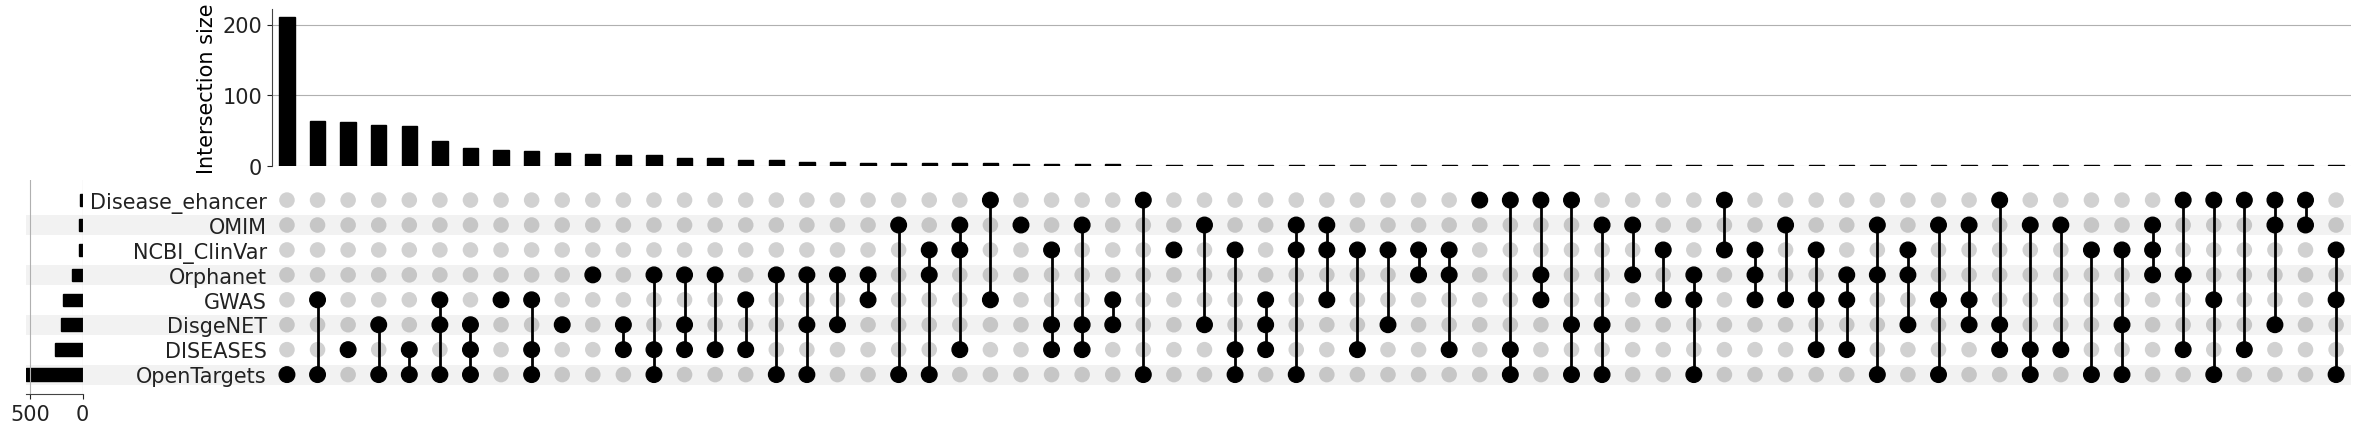

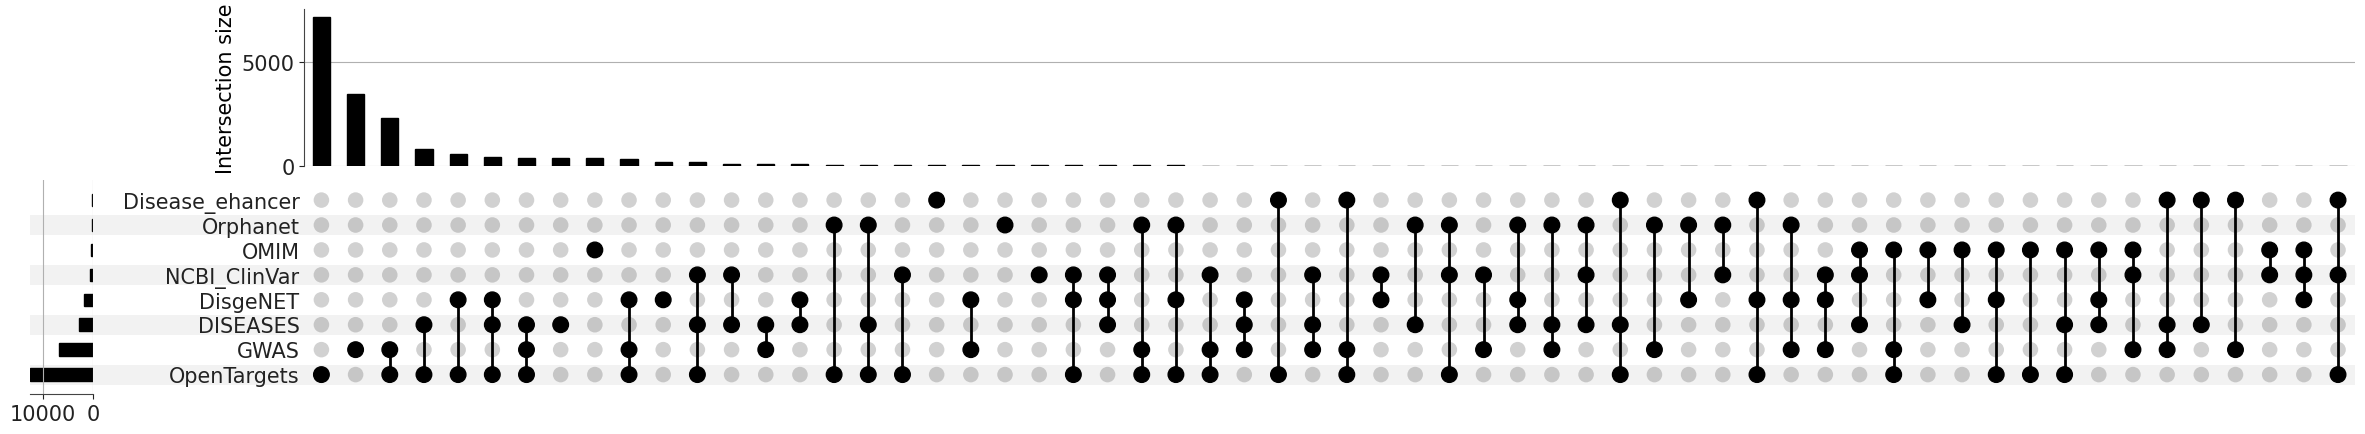

In [166]:
import pandas as pd
from itertools import chain
from upsetplot import UpSet, from_memberships
import matplotlib.pyplot as plt

BLUE = "#1f77b4"
LIGHT_GREY = "#f0f0f0"

# --- exactly 8 sources ---
sources_order = list(sources_dict_cl.keys())[:8]
disease_sets = {s: set(d.keys()) for s, d in sources_dict_cl.items() if s in sources_order}
gene_sets = {s: set(chain.from_iterable(d.values())) for s, d in sources_dict_cl.items() if s in sources_order}

def make_memberships(sets_dict):
    item_to_sets = {}
    for label, items in sets_dict.items():
        for item in items:
            item_to_sets.setdefault(item, []).append(label)
    return list(item_to_sets.values())

def style_after_plot(upset, label_thresh=4, fontsize=15):
    axd = getattr(upset, "ax_dict", {})

    # Top bars
    top_ax = axd.get("intersections")
    if top_ax:
        for rect in top_ax.patches:
            rect.set_facecolor(BLUE)
            rect.set_edgecolor(BLUE)
            h = rect.get_height()
            if h > label_thresh:
                top_ax.text(rect.get_x() + rect.get_width()/2, h + 0.5, f"{int(h)}",
                            ha="center", va="bottom", fontsize=fontsize)
        top_ax.tick_params(axis='x', labelsize=fontsize)
        top_ax.tick_params(axis='y', labelsize=fontsize)

    # Left bars
    side_ax = axd.get("totals")
    if side_ax:
        for rect in side_ax.patches:
            rect.set_facecolor(BLUE)
            rect.set_edgecolor(BLUE)
        side_ax.tick_params(axis='x', labelsize=fontsize)
        side_ax.tick_params(axis='y', labelsize=fontsize)

    # Dot matrix
    mat_ax = axd.get("matrix")
    if mat_ax:
        for coll in mat_ax.collections:
            offsets = coll.get_offsets()
            if len(offsets) > 0:
                # Active dots -> blue, inactive dots -> light grey
                if coll.get_facecolors().shape[0] and coll.get_facecolors()[0][0] == 0:  # black default
                    coll.set_facecolor(BLUE)
                    coll.set_edgecolor(BLUE)
                else:
                    coll.set_facecolor(LIGHT_GREY)
                    coll.set_edgecolor(LIGHT_GREY)
        mat_ax.tick_params(axis='x', labelsize=fontsize)
        mat_ax.tick_params(axis='y', labelsize=fontsize)

    # Row shading (background stripes)
    shade_ax = axd.get("shading")
    if shade_ax:
        for rect in shade_ax.patches:
            rect.set_facecolor(LIGHT_GREY)
            rect.set_edgecolor(LIGHT_GREY)
            rect.set_alpha(1.0)

def plot_and_save_upset(memberships, title, out_file, max_combination_size=3, fontsize=15):
    data = from_memberships(memberships)
    data_f = data[[sum(k) <= max_combination_size for k in data.index]]

    upset = UpSet(data_f, subset_size="count", show_counts=False, sort_by="cardinality")
    upset.plot()

    style_after_plot(upset, label_thresh=4, fontsize=fontsize)

    # plt.suptitle(title, fontsize=fontsize)
    plt.gcf().set_size_inches(30, 5)
    plt.savefig(out_file, dpi=300, bbox_inches="tight", pad_inches=0.1)
    plt.show()
    plt.close()

# --- run both ---
plot_and_save_upset(make_memberships(disease_sets),
                    "Disease Overlap — ≤3-way",
                    "disease_overlap_upset_max3.png")

plot_and_save_upset(make_memberships(gene_sets),
                    "Gene Overlap — ≤3-way",
                    "gene_overlap_upset_max3.png")





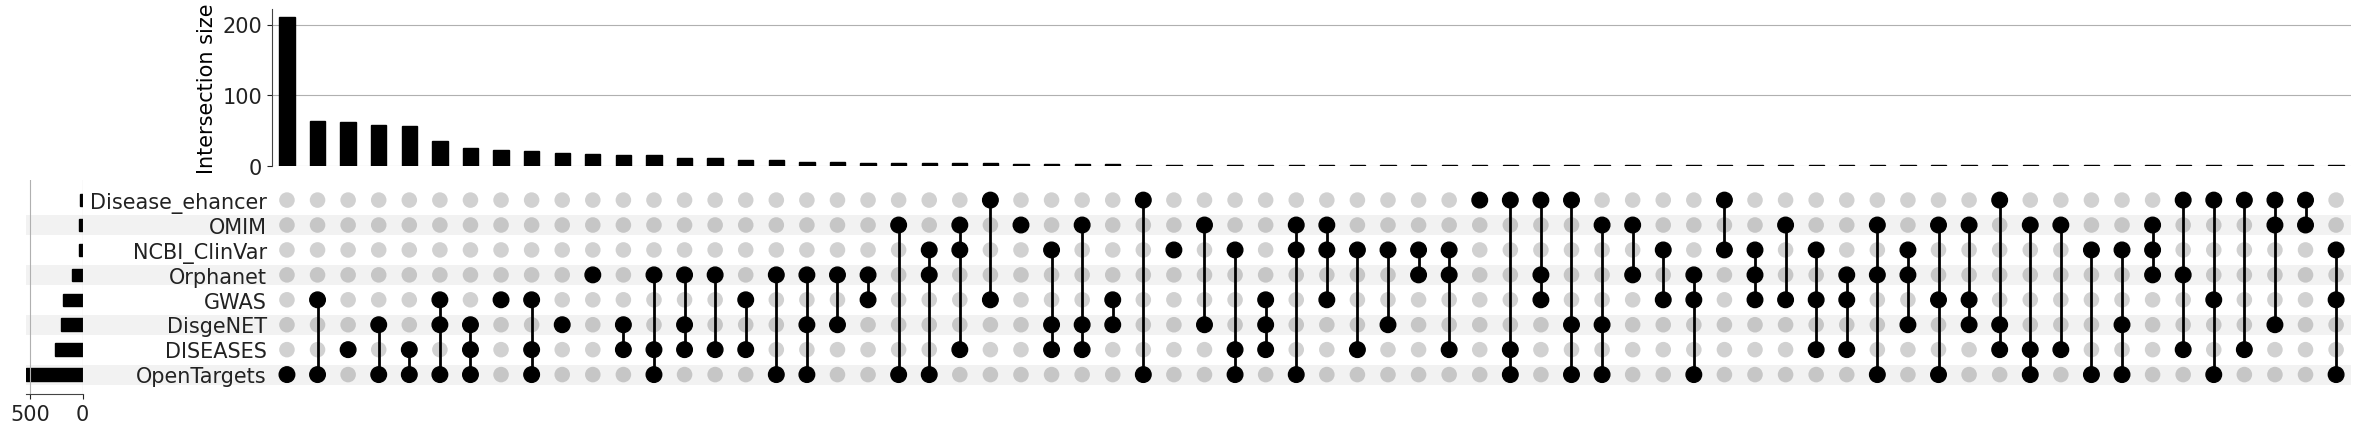

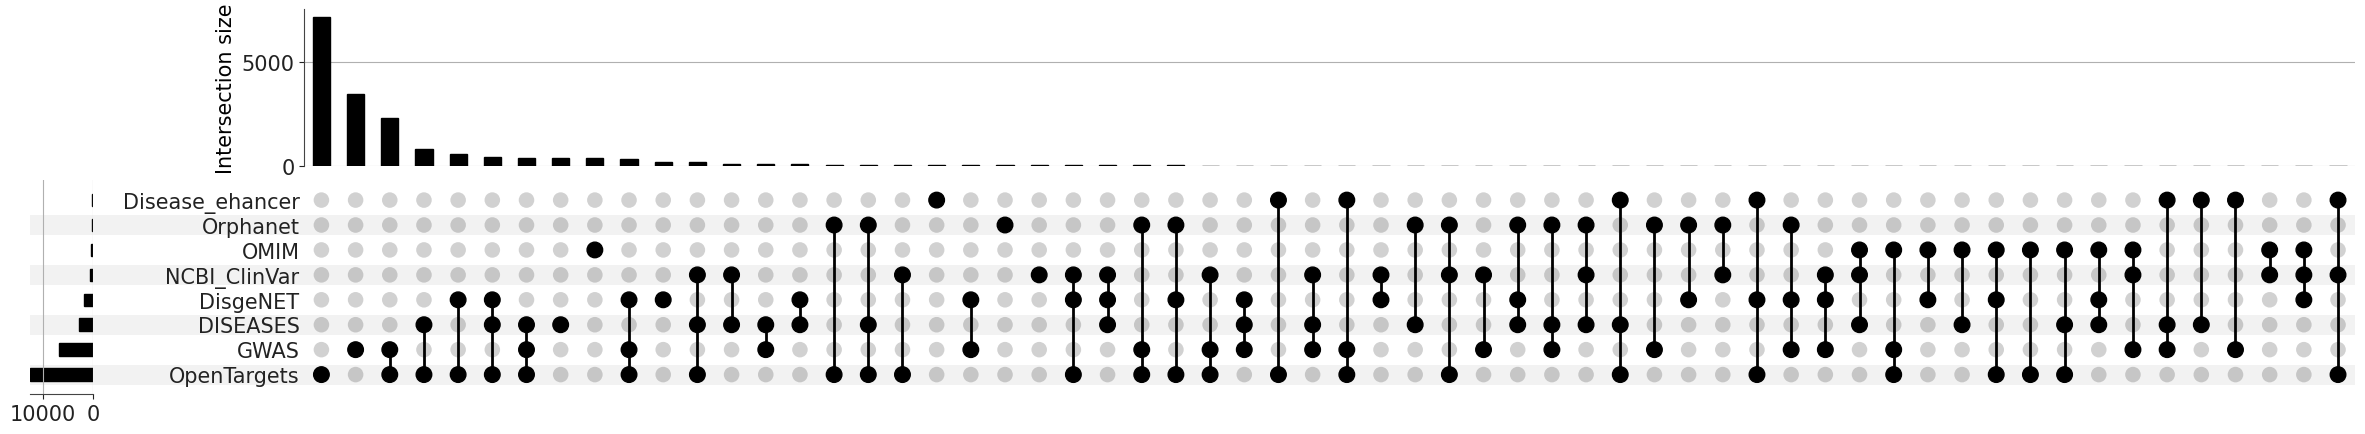

In [168]:
import pandas as pd
from itertools import chain
from upsetplot import UpSet, from_memberships
import matplotlib.pyplot as plt

BLUE = "#1f77b4"
LIGHT_GREY = "#f0f0f0"

# --- exactly 8 sources ---
sources_order = list(sources_dict_cl.keys())[:8]
disease_sets = {s: set(d.keys()) for s, d in sources_dict_cl.items() if s in sources_order}
gene_sets    = {s: set(chain.from_iterable(d.values())) for s, d in sources_dict_cl.items() if s in sources_order}

def make_memberships(sets_dict):
    item_to_sets = {}
    for label, items in sets_dict.items():
        for item in items:
            item_to_sets.setdefault(item, []).append(label)
    return list(item_to_sets.values())

def style_after_plot(upset, label_thresh=4, fontsize=15):
    axd = getattr(upset, "ax_dict", {})

    # --- Top bars (intersection sizes) ---
    top_ax = axd.get("intersections")
    if top_ax:
        for rect in top_ax.patches:
            rect.set_facecolor(BLUE)
            rect.set_edgecolor(BLUE)
        # optional labels above taller bars
        for rect in top_ax.patches:
            h = rect.get_height()
            if h > label_thresh:
                top_ax.text(rect.get_x() + rect.get_width()/2, h + 0.5, f"{int(h)}",
                            ha="center", va="bottom", fontsize=fontsize)
        top_ax.tick_params(axis='x', labelsize=fontsize)
        top_ax.tick_params(axis='y', labelsize=fontsize)

    # --- Side bars (set totals) ---
    side_ax = axd.get("totals")
    if side_ax:
        for rect in side_ax.patches:
            rect.set_facecolor(BLUE)
            rect.set_edgecolor(BLUE)
        side_ax.tick_params(axis='x', labelsize=fontsize)
        side_ax.tick_params(axis='y', labelsize=fontsize)

    # --- Row shading ---
    shade_ax = axd.get("shading")
    if shade_ax:
        for rect in shade_ax.patches:
            rect.set_facecolor(LIGHT_GREY)
            rect.set_edgecolor(LIGHT_GREY)
            rect.set_alpha(1.0)

def plot_and_save_upset(memberships, out_file, max_combination_size=3, fontsize=15):
    data = from_memberships(memberships)
    data_f = data[[sum(k) <= max_combination_size for k in data.index]]

    upset = UpSet(data_f, subset_size="count", show_counts=False, sort_by="cardinality")
    upset.plot()

    style_after_plot(upset, label_thresh=4, fontsize=fontsize)

    plt.gcf().set_size_inches(30, 5)
    plt.savefig(out_file, dpi=300, bbox_inches="tight", pad_inches=0.1)
    plt.show()
    plt.close()

# --- run both ---
plot_and_save_upset(make_memberships(disease_sets), "disease_overlap_upset_max3.png")
plot_and_save_upset(make_memberships(gene_sets),    "gene_overlap_upset_max3.png")



In [170]:
import pandas as pd
from itertools import chain

BLUE = "#1f77b4"

# exactly 8 sources (same order you used before)
sources_order = list(sources_dict_cl.keys())[:8]

# rebuild sets in case not in scope
disease_sets = {s: set(d.keys()) for s, d in sources_dict_cl.items() if s in sources_order}
gene_sets    = {s: set(chain.from_iterable(d.values())) for s, d in sources_dict_cl.items() if s in sources_order}

def sets_to_matrix(sets_dict):
    """Return a 0/1 wide matrix: rows = items, cols = set names."""
    items = sorted(set().union(*sets_dict.values()))
    df = pd.DataFrame({"item_id": items})
    for s in sources_order:
        df[s] = df["item_id"].apply(lambda x: 1 if x in sets_dict.get(s, set()) else 0)
    return df

# Write files
sets_to_matrix(disease_sets).to_csv("disease_upset_matrix.csv", index=False)
sets_to_matrix(gene_sets).to_csv("gene_upset_matrix.csv", index=False)

print("Wrote disease_upset_matrix.csv and gene_upset_matrix.csv")


Wrote disease_upset_matrix.csv and gene_upset_matrix.csv
